In [1]:
!pip install --upgrade imbalanced-learn
!pip install --upgrade scikit-learn
!pip install opencv-python-headless 
!pip install torch torchvision pandas numpy matplotlib seaborn opencv-python scikit-learn Pillow imblearn tqdm
!pip install pandas lime scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 5.5 MB/s eta 0:00:0000:01
  Attempting uninstall: sklearn-compat
    Found existing installation: sklearn-compat 0.1.5
    Uninstalling sklearn-compat-0.1.5:
      Successfully uninstalled sklearn-compat-0.1.5
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.1
    Uninstalling imbalanced-learn-0.14.1:
      Successfully uninstalled imbalanced-learn-0.14.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.


ResNet-U-Net


In [3]:
# --- NEW: Install LIME for model interpretability ---
!pip install -q lime

In [3]:
import os
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
import torchvision.transforms.functional as F_T
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from PIL import Image

# --- Imports for LIME ---
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ==========================================
# START OVERALL TIMER
# ==========================================
overall_start_time = time.time()

# --- Set Seeds for Reproducibility ---
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Set CUDA_LAUNCH_BLOCKING for easier debugging
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# --- Data Loading and Preparation ---
try:
    metadata_df = pd.read_csv('/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv')
    print("Successfully loaded metadata CSV.")
except FileNotFoundError:
    print("Error: 'T2_age_gender_evaluation.csv' not found. Please ensure the file is in the correct path.")
    metadata_df = pd.DataFrame(columns=['Patient ID', 'Age', 'Gender', 'Radiological Evaluation'])

# Rename and process columns
metadata_df.rename(columns={
    'Patient ID': 'ID',
    'Radiological Evaluation': 'radiological_evaluation'
}, inplace=True)

metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)

# Map numerical classes to names
class_name_map = {1: 'Normal', 2: 'Mild', 3: 'Severe'}
metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
metadata_df['class_label'], class_names = pd.factorize(metadata_df['class_name'])
class_map = {i: name for i, name in enumerate(class_names)}

print("\n--- Classification Task Setup ---")
print("Class Mapping for Evaluation:", class_map)

metadata_df['ID'] = metadata_df['ID'].astype(str)
valid_ids = set(metadata_df['ID'].tolist())

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        print(f"Warning: Directory '{directory}' not found. Skipping.")
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

train_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
valid_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
test_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'

train_df = pd.merge(create_dataframe_from_ids(train_dir, valid_ids), metadata_df, on='ID')
val_df = pd.merge(create_dataframe_from_ids(valid_dir, valid_ids), metadata_df, on='ID')
test_df = pd.merge(create_dataframe_from_ids(test_dir, valid_ids), metadata_df, on='ID')

print(f"\nTraining samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset, Transforms, and Model ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224), is_train=True):
        self.image_size = image_size
        self.is_train = is_train
        
    def __call__(self, image, mask):
        image = F_T.resize(image, self.image_size, interpolation=F_T.InterpolationMode.BILINEAR)
        mask = F_T.resize(mask, self.image_size, interpolation=F_T.InterpolationMode.NEAREST)
        if self.is_train:
            if random.random() > 0.5: image, mask = F_T.hflip(image), F_T.hflip(mask)
            if random.random() > 0.5: image, mask = F_T.vflip(image), F_T.vflip(mask)
            angle = random.uniform(-15, 15)
            image, mask = F_T.rotate(image, angle), F_T.rotate(mask, angle)
        image = F_T.to_tensor(image)
        mask = F_T.to_tensor(mask)
        image = F_T.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = (mask > 0).float()
        return image, mask

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
        
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_file_path']).convert('RGB')
        mask = Image.open(row['mask_file_path']).convert('L')
        class_label = torch.tensor(row['class_label'], dtype=torch.long)
        if self.transform:
            image, mask = self.transform(image, mask)
        return image, mask, class_label

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
    def forward(self, x, skip_connection):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = torch.cat([x, skip_connection], dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class UNetWithResNet50Encoder(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        base_layers = list(base_model.children())
        self.encoder0 = nn.Sequential(*base_layers[:3])
        self.encoder1 = nn.Sequential(*base_layers[3:5])
        self.encoder2 = base_layers[5]
        self.encoder3 = base_layers[6]
        self.encoder4 = base_layers[7]
        self.decoder3 = DecoderBlock(2048, 1024, 512)
        self.decoder2 = DecoderBlock(512, 512, 256)
        self.decoder1 = DecoderBlock(256, 256, 128)
        self.decoder0 = DecoderBlock(128, 64, 64)
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)
        
    def forward(self, x):
        e0 = self.encoder0(x); e1 = self.encoder1(e0); e2 = self.encoder2(e1)
        e3 = self.encoder3(e2); e4 = self.encoder4(e3)
        d3 = self.decoder3(e4, e3); d2 = self.decoder2(d3, e2)
        d1 = self.decoder1(d2, e1); d0 = self.decoder0(d1, e0)
        return self.final_conv(F.interpolate(d0, scale_factor=2, mode='bilinear', align_corners=True))

# --- Loss, Metrics, and Training Functions ---
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, inputs, targets):
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        return bce + dice_loss

def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

def train_one_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    for images, masks, _ in tqdm(loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        dice, iou = calculate_metrics(outputs, masks)
        total_dice += dice * images.size(0)
        total_iou += iou * images.size(0)
    return (running_loss / len(loader.dataset),
            total_dice / len(loader.dataset),
            total_iou / len(loader.dataset))

def evaluate_model(loader, model, loss_fn, device, class_mapping, dataset_name="Validation"):
    model.eval()
    all_preds, all_masks, all_labels = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, masks, labels in tqdm(loader, desc=f"Evaluating on {dataset_name}"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            running_loss += loss_fn(outputs, masks).item() * images.size(0)
            all_preds.append(outputs.cpu()); all_masks.append(masks.cpu()); all_labels.append(labels.cpu())
            
    all_preds, all_masks, all_labels = torch.cat(all_preds), torch.cat(all_masks), torch.cat(all_labels)
    avg_loss, (overall_dice, overall_iou) = running_loss / len(loader.dataset), calculate_metrics(all_preds, all_masks)
    
    print(f"\n--- {dataset_name} Report ---")
    print(f"Overall -> Loss: {avg_loss:.4f}, Dice: {overall_dice:.4f}, mIoU: {overall_iou:.4f}")
    
    print("--- Per-Class Metrics ---")
    for class_idx, class_name in class_mapping.items():
        indices = (all_labels == class_idx).nonzero(as_tuple=True)[0]
        if len(indices) > 0:
            class_dice, class_iou = calculate_metrics(all_preds[indices], all_masks[indices])
            print(f"Class '{class_name}' ({len(indices)} samples) -> Dice: {class_dice:.4f}, mIoU: {class_iou:.4f}")
    return avg_loss, overall_dice

# --- FULL TRAINING LOOP ---
train_dataset = LiverDataset(train_df, transform=SegmentationTransform(is_train=True))
val_dataset = LiverDataset(val_df, transform=SegmentationTransform(is_train=False))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

model = UNetWithResNet50Encoder(n_classes=1).to(device)
optimizer = AdamW(model.parameters(), lr=1e-4)
criterion = DiceBCELoss()

num_epochs = 20 
best_val_dice = 0.0

print("\n--- Starting Model Training ---")

if len(train_dataset) > 0:
    # Start training block timer
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_dice, _ = train_one_epoch(train_loader, model, optimizer, criterion, device)
        print(f"Training -> Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        
        val_loss, val_dice = evaluate_model(val_loader, model, criterion, device, class_map)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), 'best_segmentation_model1.pth')
            print(f"✅ Model Saved! New Best Dice: {best_val_dice:.4f}")
            
        epoch_time = time.time() - epoch_start_time
        print(f"⏱ Epoch {epoch+1} Time: {epoch_time:.2f} sec ({epoch_time/60:.2f} min)")
        
    # End training block timer
    training_time = time.time() - training_start_time
    print("\n==============================")
    print(f"⏱ Total Training Time : {training_time:.2f} sec")
    print(f"⏱ Total Training Time : {training_time/60:.2f} min")
    print(f"⏱ Total Training Time : {training_time/3600:.2f} hr")
    print("==============================")
else:
    print("🛑 Training dataset is empty. Cannot start training.")

# --- LIME EXPLANATION SECTION ---
print("\n--- Loading Best Model for LIME Explanation ---")
try:
    model.load_state_dict(torch.load('best_segmentation_model.pth', map_location=device))
    print("Best model weights loaded successfully for LIME.")
except FileNotFoundError:
    print("Model file 'best_segmentation_model.pth' not found. Cannot perform LIME explanation.")
    model = None

def get_pil_transform():
    return transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def get_preprocess_transform():
    return transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def batch_predict(images):
    model.eval()
    batch = torch.stack([get_preprocess_transform()(image) for image in images], dim=0).to(device).float()
    with torch.no_grad():
        logits = model(batch)
    probs = torch.sigmoid(logits)
    segmentation_confidence = probs.sum(dim=[1, 2, 3])
    return torch.stack([1 - segmentation_confidence, segmentation_confidence], dim=1).cpu().numpy()

def generate_lime_explanation(dataset, model, class_mapping):
    if model is None or len(dataset) == 0:
        print("Skipping LIME: model or dataset not available.")
        return
    print("\n--- Generating LIME Explanations for Each Class ---")
    explainer = lime_image.LimeImageExplainer()
    test_df_viz = dataset.dataframe.drop_duplicates(subset=['class_label'])

    for _, row in test_df_viz.iterrows():
        class_name = row['class_name']
        image_path = row['image_file_path']
        original_image = Image.open(image_path).convert('RGB').resize((224, 224))
        
        print(f"\nExplaining a sample for class: '{class_name}'...")
        explanation = explainer.explain_instance(np.array(original_image), batch_predict, top_labels=1, hide_color=0, num_samples=1000)
        
        temp, mask = explanation.get_image_and_mask(label=1, positive_only=True, num_features=5, hide_rest=True)
        
        img_tensor = get_pil_transform()(original_image).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_mask = (torch.sigmoid(model(img_tensor)) > 0.5).float().cpu().squeeze(0).permute(1, 2, 0)
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"LIME Explanation for Class: {class_name}", fontsize=16)
        axes[0].imshow(original_image); axes[0].set_title("Original Image"); axes[0].axis('off')
        axes[1].imshow(pred_mask, cmap='gray'); axes[1].set_title("Model's Predicted Mask"); axes[1].axis('off')
        axes[2].imshow(mark_boundaries(temp / 2 + 0.5, mask)); axes[2].set_title("LIME: Important Regions"); axes[2].axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# Run LIME on the test dataset with Lime Timer
lime_start_time = time.time()
test_dataset = LiverDataset(test_df, transform=None) # Use untransformed images for LIME
generate_lime_explanation(test_dataset, model, class_map)
lime_time = time.time() - lime_start_time

print("\n==============================")
print(f"⏱ Total LIME Time : {lime_time:.2f} sec")
print(f"⏱ Total LIME Time : {lime_time/60:.2f} min")
print("==============================")

# ==========================================
# END OVERALL TIMER & PRINT REPORT
# ==========================================
overall_time = time.time() - overall_start_time

print("\n" + "========================================")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time:.2f} sec")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/60:.2f} min")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/3600:.2f} hr")
print("========================================")

Using device: cuda ⚙️
Successfully loaded metadata CSV.

--- Classification Task Setup ---
Class Mapping for Evaluation: {0: 'Severe', 1: 'Normal', 2: 'Mild'}

Training samples: 5364, Validation samples: 674, Test samples: 664
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]



--- Starting Model Training ---

Epoch 1/20


Training: 100%|██████████| 336/336 [02:04<00:00,  2.69it/s]


Training -> Loss: 0.8574, Dice: 0.8365


...


--- Validation Report ---
Overall -> Loss: 0.0812, Dice: 0.9525, mIoU: 0.9093
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.9197, mIoU: 0.8513
Class 'Normal' (309 samples) -> Dice: 0.9632, mIoU: 0.9291
Class 'Mild' (189 samples) -> Dice: 0.9557, mIoU: 0.9151
⏱ Epoch 19 Time: 135.60 sec (2.26 min)

Epoch 20/20


Training: 100%|██████████| 336/336 [02:09<00:00,  2.60it/s]


Training -> Loss: 0.0681, Dice: 0.9577


Evaluating on Validation: 100%|██████████| 43/43 [00:05<00:00,  7.43it/s]



--- Validation Report ---
Overall -> Loss: 0.0953, Dice: 0.9443, mIoU: 0.8944
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.9177, mIoU: 0.8480
Class 'Normal' (309 samples) -> Dice: 0.9533, mIoU: 0.9108
Class 'Mild' (189 samples) -> Dice: 0.9464, mIoU: 0.8983
⏱ Epoch 20 Time: 135.73 sec (2.26 min)

⏱ Total Training Time : 2712.21 sec
⏱ Total Training Time : 45.20 min
⏱ Total Training Time : 0.75 hr

--- Loading Best Model for LIME Explanation ---
Model file 'best_segmentation_model.pth' not found. Cannot perform LIME explanation.
Skipping LIME: model or dataset not available.

⏱ Total LIME Time : 0.00 sec
⏱ Total LIME Time : 0.00 min

⏱ COMPLETE CODE EXECUTION TIME : 2722.71 sec
⏱ COMPLETE CODE EXECUTION TIME : 45.38 min
⏱ COMPLETE CODE EXECUTION TIME : 0.76 hr


TransUNet++

Using device: cuda ⚙️
Successfully loaded metadata CSV.

--- Classification Task Setup ---
Class Mapping for Evaluation: {0: 'Severe', 1: 'Normal', 2: 'Mild'}

Training samples: 5364, Validation samples: 674, Test samples: 664

--- Starting Model Training with TransUNet++ ---

Epoch 1/20


Training: 100%|██████████| 336/336 [05:26<00:00,  1.03it/s]


Training -> Loss: 0.8876, Dice: 0.8411


Evaluating on Validation: 100%|██████████| 43/43 [00:12<00:00,  3.31it/s]



--- Validation Report ---
Overall -> Loss: 0.7118, Dice: 0.8928, mIoU: 0.8063
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.8359, mIoU: 0.7180
Class 'Normal' (309 samples) -> Dice: 0.9071, mIoU: 0.8300
Class 'Mild' (189 samples) -> Dice: 0.9041, mIoU: 0.8250
✅ Model Saved! New Best Dice: 0.8928
⏱ Epoch 1 Time: 341.05 sec (5.68 min)

Epoch 2/20


...

Training -> Loss: 0.0721, Dice: 0.9555


Evaluating on Validation: 100%|██████████| 43/43 [00:12<00:00,  3.33it/s]



--- Validation Report ---
Overall -> Loss: 0.0764, Dice: 0.9548, mIoU: 0.9135
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.9347, mIoU: 0.8774
Class 'Normal' (309 samples) -> Dice: 0.9602, mIoU: 0.9235
Class 'Mild' (189 samples) -> Dice: 0.9585, mIoU: 0.9204
⏱ Epoch 20 Time: 336.29 sec (5.60 min)

⏱ Total Training Time : 6740.53 sec
⏱ Total Training Time : 112.34 min
⏱ Total Training Time : 1.87 hr

--- Loading Best Model for LIME Explanation ---
Best model weights loaded successfully for LIME.

--- Generating LIME Explanations for Each Class ---

Explaining a sample for class: 'Mild'...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..105.0].


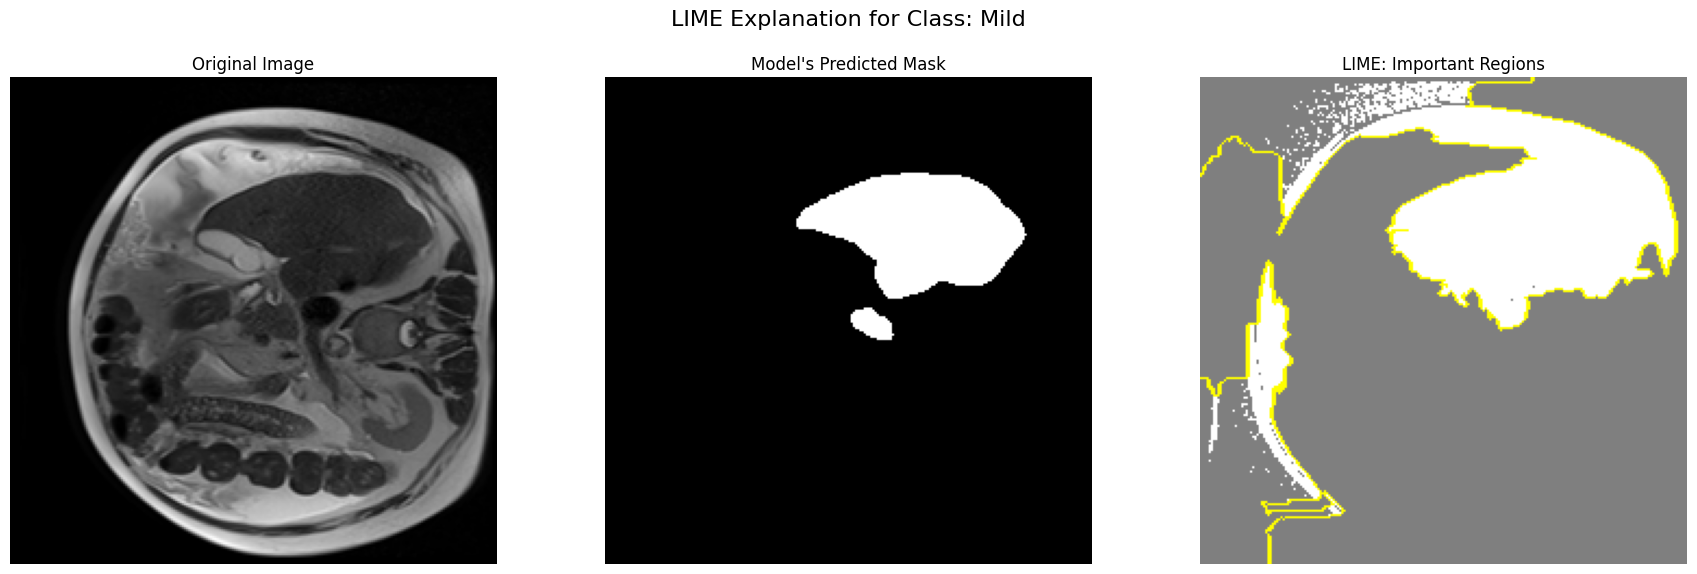


Explaining a sample for class: 'Normal'...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..81.5].


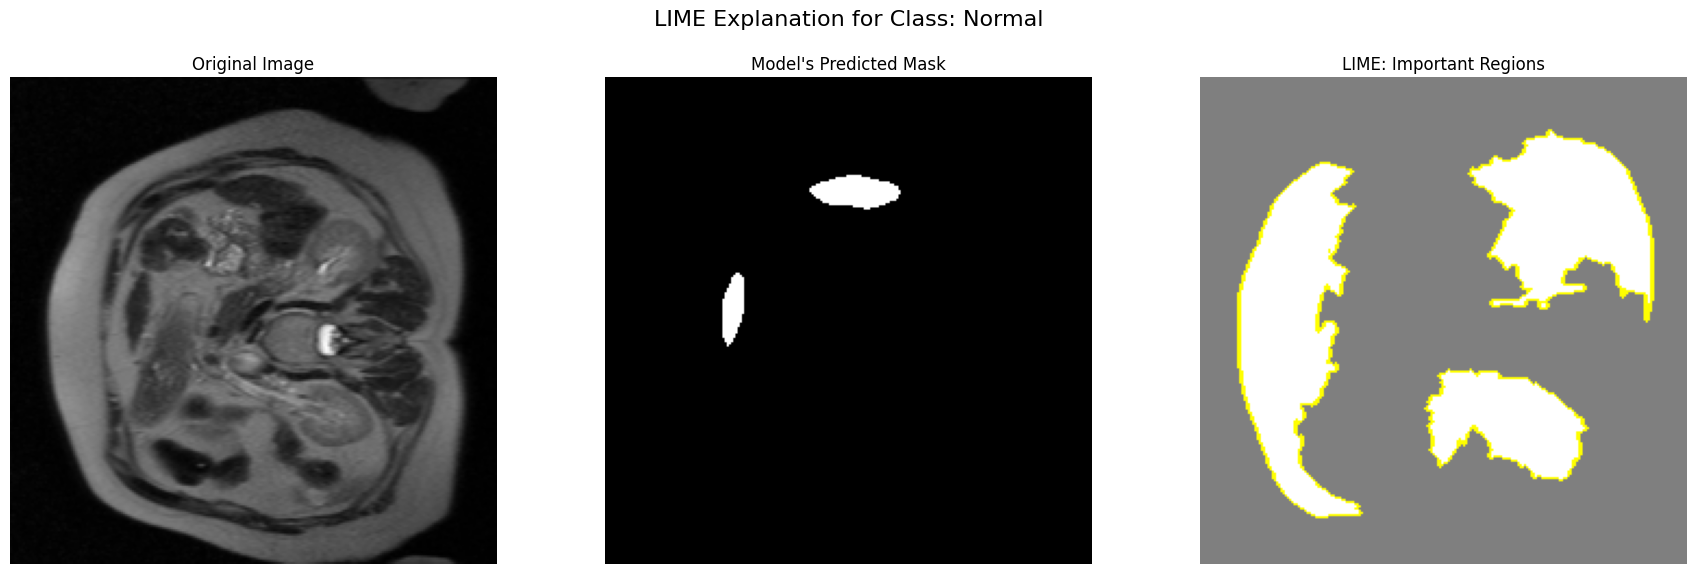


Explaining a sample for class: 'Severe'...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..103.0].


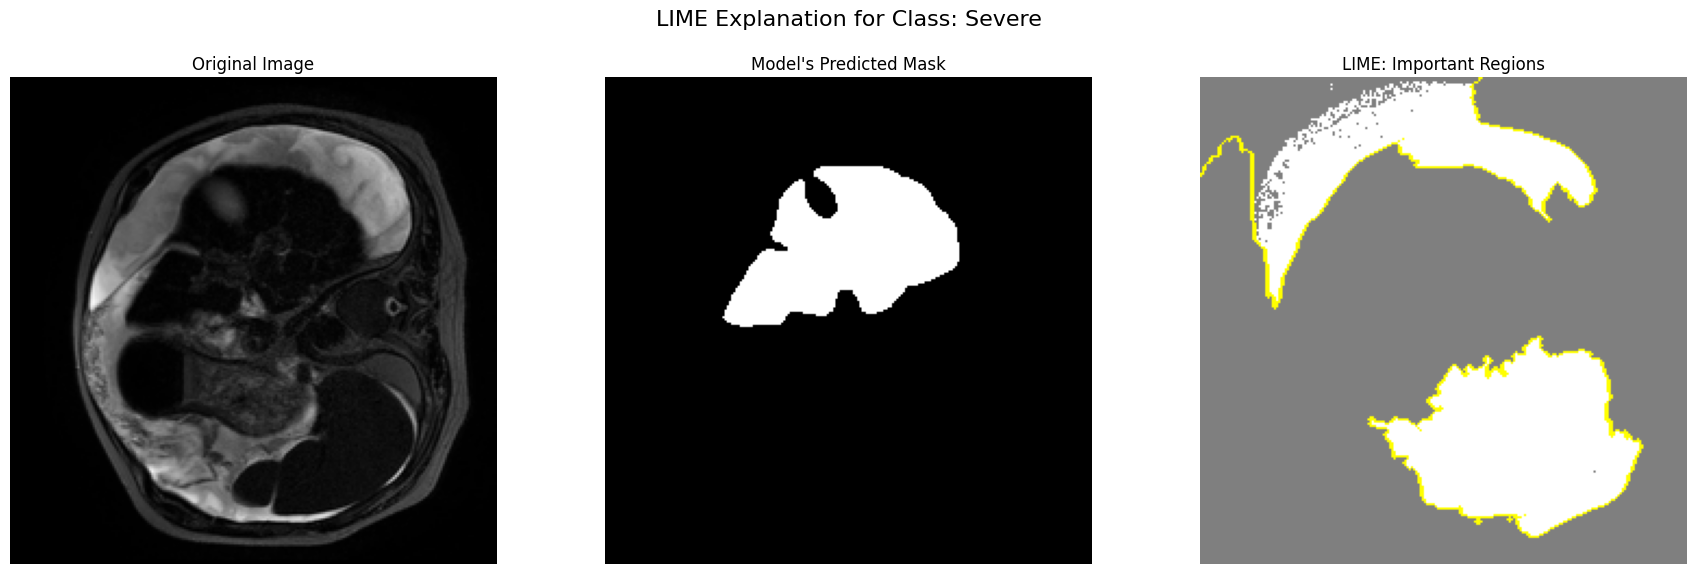


⏱ Total LIME Time : 72.36 sec
⏱ Total LIME Time : 1.21 min

⏱ COMPLETE CODE EXECUTION TIME : 6824.26 sec
⏱ COMPLETE CODE EXECUTION TIME : 113.74 min
⏱ COMPLETE CODE EXECUTION TIME : 1.90 hr


In [4]:
import os
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
import torchvision.transforms.functional as F_T
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from PIL import Image

# --- Imports for LIME ---
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ==========================================
# START OVERALL TIMER
# ==========================================
overall_start_time = time.time()

# --- Set Seeds for Reproducibility ---
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Set CUDA_LAUNCH_BLOCKING for easier debugging
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# --- Data Loading and Preparation ---
try:
    metadata_df = pd.read_csv('/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv')
    print("Successfully loaded metadata CSV.")
except FileNotFoundError:
    print("Error: 'T2_age_gender_evaluation.csv' not found. Please ensure the file is in the correct path.")
    metadata_df = pd.DataFrame(columns=['Patient ID', 'Age', 'Gender', 'Radiological Evaluation'])

# Rename and process columns
metadata_df.rename(columns={
    'Patient ID': 'ID',
    'Radiological Evaluation': 'radiological_evaluation'
}, inplace=True)
metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)

# Map numerical classes to names
class_name_map = {1: 'Normal', 2: 'Mild', 3: 'Severe'}
metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
metadata_df['class_label'], class_names = pd.factorize(metadata_df['class_name'])
class_map = {i: name for i, name in enumerate(class_names)}

print("\n--- Classification Task Setup ---")
print("Class Mapping for Evaluation:", class_map)

metadata_df['ID'] = metadata_df['ID'].astype(str)
valid_ids = set(metadata_df['ID'].tolist())

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        print(f"Warning: Directory '{directory}' not found. Skipping.")
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

train_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
valid_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
test_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'

train_df = pd.merge(create_dataframe_from_ids(train_dir, valid_ids), metadata_df, on='ID')
val_df = pd.merge(create_dataframe_from_ids(valid_dir, valid_ids), metadata_df, on='ID')
test_df = pd.merge(create_dataframe_from_ids(test_dir, valid_ids), metadata_df, on='ID')

print(f"\nTraining samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset, Transforms, and Model ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224), is_train=True):
        self.image_size = image_size
        self.is_train = is_train
    def __call__(self, image, mask):
        image = F_T.resize(image, self.image_size, interpolation=F_T.InterpolationMode.BILINEAR)
        mask = F_T.resize(mask, self.image_size, interpolation=F_T.InterpolationMode.NEAREST)
        if self.is_train:
            if random.random() > 0.5: image, mask = F_T.hflip(image), F_T.hflip(mask)
            if random.random() > 0.5: image, mask = F_T.vflip(image), F_T.vflip(mask)
            angle = random.uniform(-15, 15)
            image, mask = F_T.rotate(image, angle), F_T.rotate(mask, angle)
        image = F_T.to_tensor(image)
        mask = F_T.to_tensor(mask)
        image = F_T.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = (mask > 0).float()
        return image, mask

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_file_path']).convert('RGB')
        mask = Image.open(row['mask_file_path']).convert('L')
        class_label = torch.tensor(row['class_label'], dtype=torch.long)
        if self.transform:
            image, mask = self.transform(image, mask)
        return image, mask, class_label

# --- NEW MODEL: TransUNet++ ---

class ConvBlock(nn.Module):
    """
    Standard convolutional block: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class TransUNetPP(nn.Module):
    """
    TransUNet++ Architecture
    Combines a ResNet50 CNN backbone, a Transformer Encoder bottleneck, and a U-Net++ style decoder.
    """
    def __init__(self, n_classes=1, img_dim=224, vit_dim=768, vit_depth=12, vit_heads=12):
        super().__init__()

        # --- CNN Encoder (ResNet50 Backbone) ---
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        base_layers = list(base_model.children())
        self.encoder0 = nn.Sequential(*base_layers[:3])      # Out: 64, /2
        self.encoder1 = nn.Sequential(*base_layers[3:5])     # Out: 256, /4
        self.encoder2 = base_layers[5]                       # Out: 512, /8
        self.encoder3 = base_layers[6]                       # Out: 1024, /16
        self.encoder4 = base_layers[7]                       # Out: 2048, /32

        # --- Transformer Encoder (Bottleneck) ---
        num_patches = (img_dim // 32) ** 2
        self.patch_dim = 2048 # Output channels from encoder4
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, vit_dim))
        self.patch_to_embedding = nn.Linear(self.patch_dim, vit_dim)
        transformer_layer = nn.TransformerEncoderLayer(d_model=vit_dim, nhead=vit_heads, dim_feedforward=vit_dim * 4, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(transformer_layer, num_layers=vit_depth)
        self.transformer_output_to_conv = nn.Sequential(
            nn.Linear(vit_dim, self.patch_dim),
            nn.LayerNorm(self.patch_dim)
        )

        # --- U-Net++ Decoder ---
        d_ch = {'d0': 64, 'd1': 128, 'd2': 256, 'd3': 512, 'd4': 1024}

        # Node X_0,0
        self.X_0_0 = ConvBlock(64, d_ch['d0'])
        # Node X_1,0
        self.X_1_0 = ConvBlock(256, d_ch['d1'])
        # Node X_0,1
        self.X_0_1 = ConvBlock(d_ch['d0'] + d_ch['d1'], d_ch['d0'])

        # Node X_2,0
        self.X_2_0 = ConvBlock(512, d_ch['d2'])
        # Node X_1,1
        self.X_1_1 = ConvBlock(d_ch['d1'] + d_ch['d2'], d_ch['d1'])
        # Node X_0,2
        self.X_0_2 = ConvBlock(d_ch['d0']*2 + d_ch['d1'], d_ch['d0'])

        # Node X_3,0
        self.X_3_0 = ConvBlock(1024, d_ch['d3'])
        # Node X_2,1
        self.X_2_1 = ConvBlock(d_ch['d2'] + d_ch['d3'], d_ch['d2'])
        # Node X_1,2
        self.X_1_2 = ConvBlock(d_ch['d1']*2 + d_ch['d2'], d_ch['d1'])
        # Node X_0,3
        self.X_0_3 = ConvBlock(d_ch['d0']*3 + d_ch['d1'], d_ch['d0'])

        # Node X_4,0 (from Transformer)
        self.X_4_0 = ConvBlock(2048, d_ch['d4'])
        # Node X_3,1
        self.X_3_1 = ConvBlock(d_ch['d3'] + d_ch['d4'], d_ch['d3'])
        # Node X_2,2
        self.X_2_2 = ConvBlock(d_ch['d2']*2 + d_ch['d3'], d_ch['d2'])
        # Node X_1,3
        self.X_1_3 = ConvBlock(d_ch['d1']*3 + d_ch['d2'], d_ch['d1'])
        # Node X_0,4
        self.X_0_4 = ConvBlock(d_ch['d0']*4 + d_ch['d1'], d_ch['d0'])

        # Upsampling layer
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Final Convolution
        self.final_conv = nn.Conv2d(d_ch['d0'], n_classes, kernel_size=1)

    def forward(self, x):
        # --- CNN Encoder Path ---
        e0_out = self.encoder0(x)     # (bs, 64, 112, 112)
        e1_out = self.encoder1(e0_out) # (bs, 256, 56, 56)
        e2_out = self.encoder2(e1_out) # (bs, 512, 28, 28)
        e3_out = self.encoder3(e2_out) # (bs, 1024, 14, 14)
        e4_out = self.encoder4(e3_out) # (bs, 2048, 7, 7)

        # --- Transformer Bottleneck ---
        bs, _, h, w = e4_out.shape
        transformer_input = e4_out.flatten(2).transpose(1, 2) # (bs, 49, 2048)
        transformer_input = self.patch_to_embedding(transformer_input) # (bs, 49, vit_dim)
        transformer_input = transformer_input + self.pos_embedding
        transformer_output = self.transformer_encoder(transformer_input) # (bs, 49, vit_dim)
        transformer_output = self.transformer_output_to_conv(transformer_output) # (bs, 49, 2048)
        transformer_output = transformer_output.transpose(1, 2).view(bs, self.patch_dim, h, w) # (bs, 2048, 7, 7)

        # --- U-Net++ Decoder Path ---
        x0_0 = self.X_0_0(e0_out)
        x1_0 = self.X_1_0(e1_out)
        x0_1 = self.X_0_1(torch.cat([x0_0, self.upsample(x1_0)], 1))

        x2_0 = self.X_2_0(e2_out)
        x1_1 = self.X_1_1(torch.cat([x1_0, self.upsample(x2_0)], 1))
        x0_2 = self.X_0_2(torch.cat([x0_0, x0_1, self.upsample(x1_1)], 1))

        x3_0 = self.X_3_0(e3_out)
        x2_1 = self.X_2_1(torch.cat([x2_0, self.upsample(x3_0)], 1))
        x1_2 = self.X_1_2(torch.cat([x1_0, x1_1, self.upsample(x2_1)], 1))
        x0_3 = self.X_0_3(torch.cat([x0_0, x0_1, x0_2, self.upsample(x1_2)], 1))

        x4_0 = self.X_4_0(transformer_output) # Using transformer output as the bottleneck
        x3_1 = self.X_3_1(torch.cat([x3_0, self.upsample(x4_0)], 1))
        x2_2 = self.X_2_2(torch.cat([x2_0, x2_1, self.upsample(x3_1)], 1))
        x1_3 = self.X_1_3(torch.cat([x1_0, x1_1, x1_2, self.upsample(x2_2)], 1))
        x0_4 = self.X_0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.upsample(x1_3)], 1))

        # Final upsampling and convolution
        output = self.final_conv(x0_4)
        output = F.interpolate(output, scale_factor=2, mode='bilinear', align_corners=True) # To match original input size
        return output

# --- Loss, Metrics, and Training Functions ---
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        return bce + dice_loss

def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

def train_one_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    for images, masks, _ in tqdm(loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        dice, iou = calculate_metrics(outputs, masks)
        total_dice += dice * images.size(0)
        total_iou += iou * images.size(0)
    return (running_loss / len(loader.dataset),
            total_dice / len(loader.dataset),
            total_iou / len(loader.dataset))

def evaluate_model(loader, model, loss_fn, device, class_mapping, dataset_name="Validation"):
    model.eval()
    all_preds, all_masks, all_labels = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, masks, labels in tqdm(loader, desc=f"Evaluating on {dataset_name}"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            running_loss += loss_fn(outputs, masks).item() * images.size(0)
            all_preds.append(outputs.cpu()); all_masks.append(masks.cpu()); all_labels.append(labels.cpu())
    all_preds, all_masks, all_labels = torch.cat(all_preds), torch.cat(all_masks), torch.cat(all_labels)
    
    avg_loss, (overall_dice, overall_iou) = running_loss / len(loader.dataset), calculate_metrics(all_preds, all_masks)
    print(f"\n--- {dataset_name} Report ---")
    print(f"Overall -> Loss: {avg_loss:.4f}, Dice: {overall_dice:.4f}, mIoU: {overall_iou:.4f}")
    
    print("--- Per-Class Metrics ---")
    for class_idx, class_name in class_mapping.items():
        indices = (all_labels == class_idx).nonzero(as_tuple=True)[0]
        if len(indices) > 0:
            class_dice, class_iou = calculate_metrics(all_preds[indices], all_masks[indices])
            print(f"Class '{class_name}' ({len(indices)} samples) -> Dice: {class_dice:.4f}, mIoU: {class_iou:.4f}")
    return avg_loss, overall_dice

# --- FULL TRAINING LOOP ---
train_dataset = LiverDataset(train_df, transform=SegmentationTransform(is_train=True))
val_dataset = LiverDataset(val_df, transform=SegmentationTransform(is_train=False))
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# Instantiate the new TransUNetPP model
model = TransUNetPP(n_classes=1).to(device)
optimizer = AdamW(model.parameters(), lr=1e-4)
criterion = DiceBCELoss()
num_epochs = 20 
best_val_dice = 0.0

print("\n--- Starting Model Training with TransUNet++ ---")
if len(train_dataset) > 0:
    # Start training block timer
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_dice, _ = train_one_epoch(train_loader, model, optimizer, criterion, device)
        print(f"Training -> Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        
        val_loss, val_dice = evaluate_model(val_loader, model, criterion, device, class_map)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), 'best_segmentation_model.pth')
            print(f"✅ Model Saved! New Best Dice: {best_val_dice:.4f}")
            
        epoch_time = time.time() - epoch_start_time
        print(f"⏱ Epoch {epoch+1} Time: {epoch_time:.2f} sec ({epoch_time/60:.2f} min)")
        
    # End training block timer
    training_time = time.time() - training_start_time
    print("\n==============================")
    print(f"⏱ Total Training Time : {training_time:.2f} sec")
    print(f"⏱ Total Training Time : {training_time/60:.2f} min")
    print(f"⏱ Total Training Time : {training_time/3600:.2f} hr")
    print("==============================")
else:
    print("🛑 Training dataset is empty. Cannot start training.")

# --- LIME EXPLANATION SECTION ---
print("\n--- Loading Best Model for LIME Explanation ---")
try:
    model = TransUNetPP(n_classes=1).to(device)
    model.load_state_dict(torch.load('best_segmentation_model.pth', map_location=device))
    print("Best model weights loaded successfully for LIME.")
except FileNotFoundError:
    print("Model file 'best_segmentation_model.pth' not found. Cannot perform LIME explanation.")
    model = None

def get_pil_transform():
    return transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def get_preprocess_transform():
    return transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def batch_predict(images):
    model.eval()
    batch = torch.stack([get_preprocess_transform()(image) for image in images], dim=0).to(device).float()
    with torch.no_grad():
        logits = model(batch)
    probs = torch.sigmoid(logits)
    segmentation_confidence = probs.sum(dim=[1, 2, 3])
    return torch.stack([1 - segmentation_confidence, segmentation_confidence], dim=1).cpu().numpy()

def generate_lime_explanation(dataset, model, class_mapping):
    if model is None or len(dataset) == 0:
        print("Skipping LIME: model or dataset not available.")
        return

    print("\n--- Generating LIME Explanations for Each Class ---")
    explainer = lime_image.LimeImageExplainer()
    test_df_viz = dataset.dataframe.drop_duplicates(subset=['class_label'])

    for _, row in test_df_viz.iterrows():
        class_name = row['class_name']
        image_path = row['image_file_path']
        original_image = Image.open(image_path).convert('RGB').resize((224, 224))
        
        print(f"\nExplaining a sample for class: '{class_name}'...")
        explanation = explainer.explain_instance(np.array(original_image), batch_predict, top_labels=1, hide_color=0, num_samples=1000)
        
        temp, mask = explanation.get_image_and_mask(label=1, positive_only=True, num_features=5, hide_rest=True)
        
        img_tensor = get_pil_transform()(original_image).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_mask = (torch.sigmoid(model(img_tensor)) > 0.5).float().cpu().squeeze(0).permute(1, 2, 0)
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"LIME Explanation for Class: {class_name}", fontsize=16)
        axes[0].imshow(original_image); axes[0].set_title("Original Image"); axes[0].axis('off')
        axes[1].imshow(pred_mask, cmap='gray'); axes[1].set_title("Model's Predicted Mask"); axes[1].axis('off')
        axes[2].imshow(mark_boundaries(temp / 2 + 0.5, mask)); axes[2].set_title("LIME: Important Regions"); axes[2].axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# Run LIME on the test dataset with Lime Timer
lime_start_time = time.time()
test_dataset = LiverDataset(test_df, transform=None) 
generate_lime_explanation(test_dataset, model, class_map)
lime_time = time.time() - lime_start_time

print("\n==============================")
print(f"⏱ Total LIME Time : {lime_time:.2f} sec")
print(f"⏱ Total LIME Time : {lime_time/60:.2f} min")
print("==============================")

# ==========================================
# END OVERALL TIMER & PRINT REPORT
# ==========================================
overall_time = time.time() - overall_start_time

print("\n" + "========================================")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time:.2f} sec")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/60:.2f} min")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/3600:.2f} hr")
print("========================================")

AttentionUnet+ with deeplabv3


Using device: cuda ⚙️
Successfully loaded metadata CSV.

--- Classification Task Setup ---
Class Mapping for Evaluation: {0: 'Severe', 1: 'Normal', 2: 'Mild'}

Training samples: 5364, Validation samples: 674, Test samples: 664
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s] 



--- Model Selected: Attention U-Net ---
--- Starting Model Training for AttentionUNet ---

Epoch 1/20


Training: 100%|██████████| 336/336 [03:01<00:00,  1.85it/s]


Training -> Loss: 0.7480, Dice: 0.8340


...


--- Validation Report ---
Overall -> Loss: 0.0828, Dice: 0.9505, mIoU: 0.9057
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.9317, mIoU: 0.8720
Class 'Normal' (309 samples) -> Dice: 0.9570, mIoU: 0.9175
Class 'Mild' (189 samples) -> Dice: 0.9520, mIoU: 0.9083
⏱ Epoch 19 Time: 197.90 sec (3.30 min)

Epoch 20/20


Training: 100%|██████████| 336/336 [03:08<00:00,  1.78it/s]


Training -> Loss: 0.0695, Dice: 0.9559


Evaluating on Validation: 100%|██████████| 43/43 [00:08<00:00,  5.16it/s]



--- Validation Report ---
Overall -> Loss: 0.0720, Dice: 0.9565, mIoU: 0.9165
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.9375, mIoU: 0.8824
Class 'Normal' (309 samples) -> Dice: 0.9643, mIoU: 0.9311
Class 'Mild' (189 samples) -> Dice: 0.9561, mIoU: 0.9158
✅ Model Saved! New Best Dice: 0.9565
⏱ Epoch 20 Time: 198.38 sec (3.31 min)

⏱ Total Training Time : 3934.81 sec
⏱ Total Training Time : 65.58 min
⏱ Total Training Time : 1.09 hr

--- Generating Prediction Visualizations ---
Best model weights loaded for visualization.


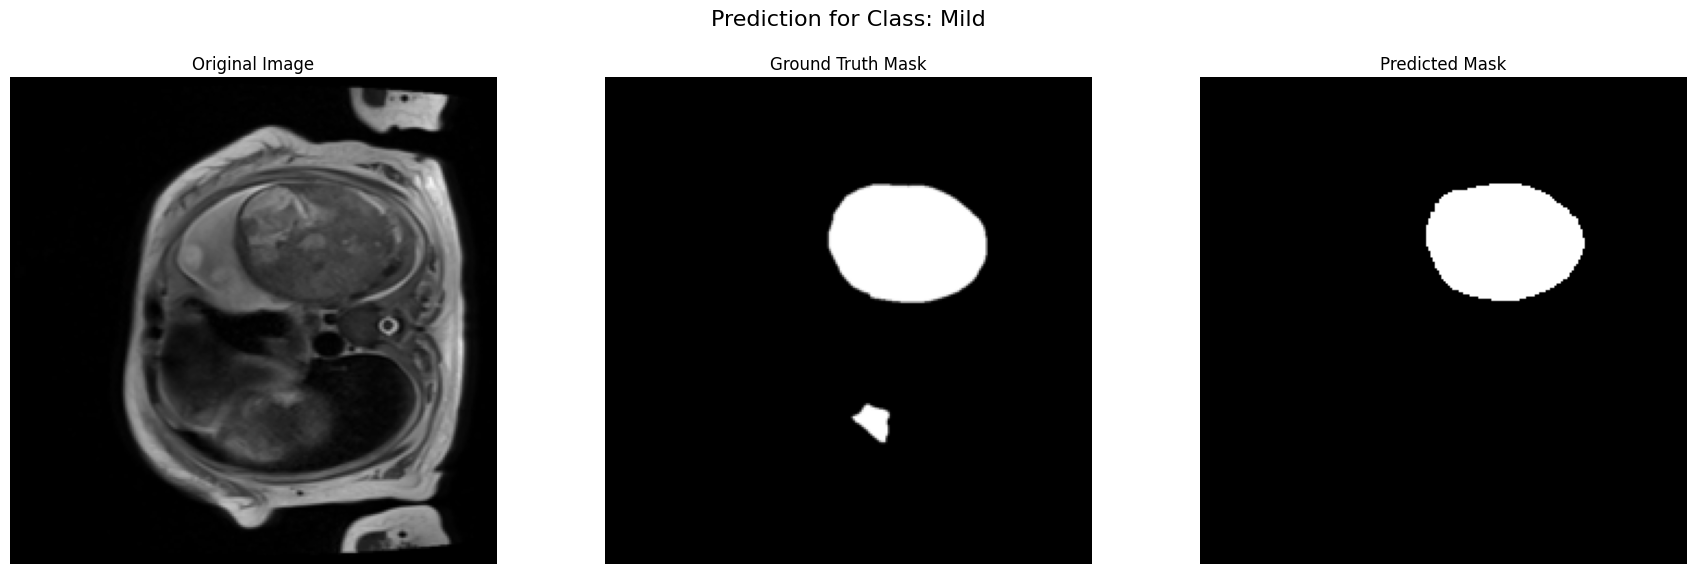

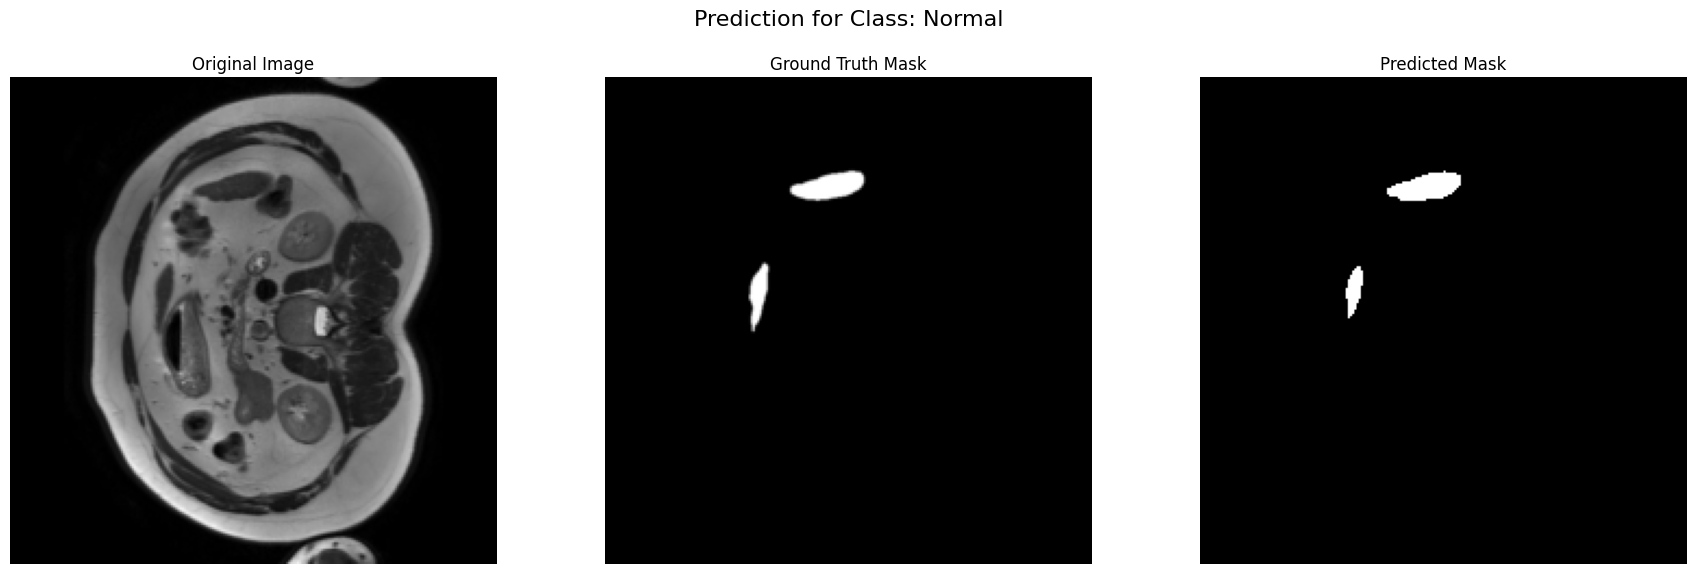

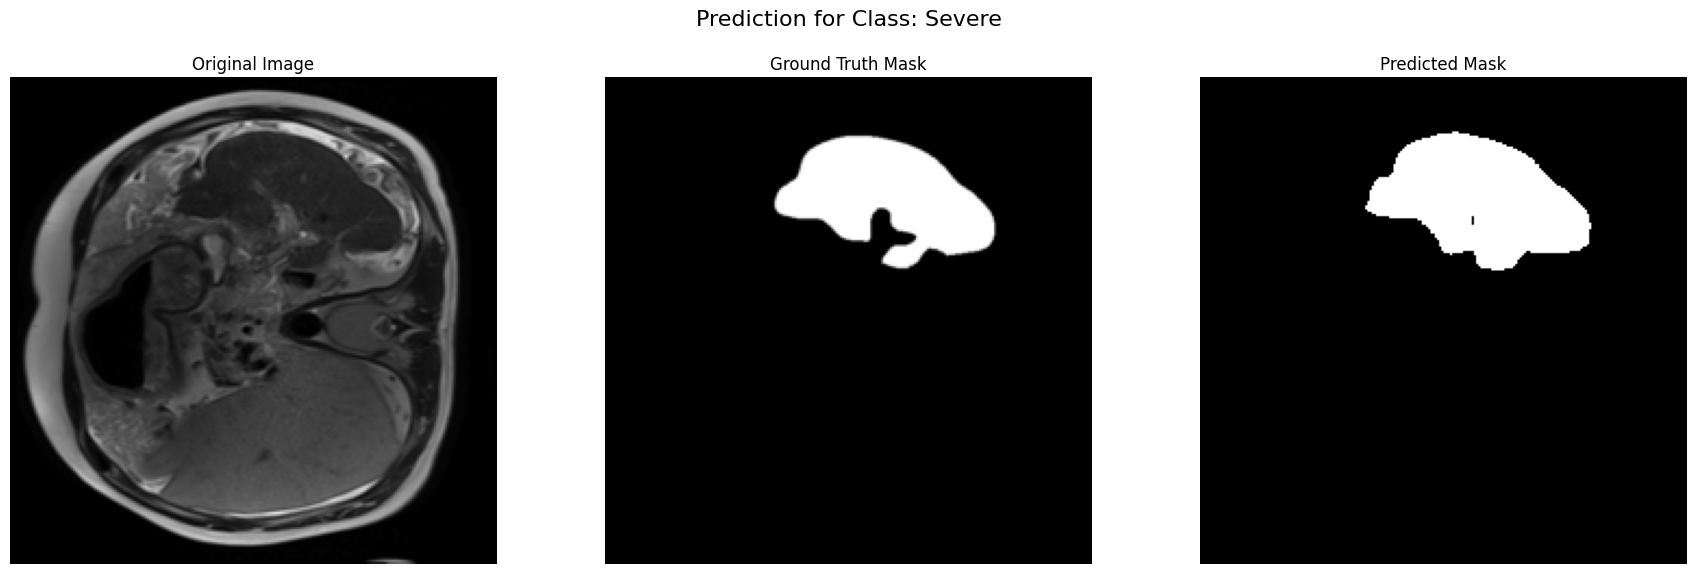


⏱ Total Visualization Time : 1.83 sec
⏱ Total Visualization Time : 0.03 min

⏱ COMPLETE CODE EXECUTION TIME : 3972.82 sec
⏱ COMPLETE CODE EXECUTION TIME : 66.21 min
⏱ COMPLETE CODE EXECUTION TIME : 1.10 hr


In [4]:
import os
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
import torchvision.transforms.functional as F_T
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
from PIL import Image

# ==========================================
# START OVERALL TIMER
# ==========================================
overall_start_time = time.time()

# --- CONFIGURATION ---
# Choose which model to use: 'AttentionUNet' or 'DeepLabV3+'
MODEL_CHOICE = 'AttentionUNet' 

# --- Set Seeds for Reproducibility ---
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Set CUDA_LAUNCH_BLOCKING for easier debugging
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# --- Data Loading and Preparation (UPDATED PATHS) ---
try:
    metadata_df = pd.read_csv('/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv')
    print("Successfully loaded metadata CSV.")
except FileNotFoundError:
    print("Error: Metadata CSV not found. Please ensure the path is correct.")
    metadata_df = pd.DataFrame(columns=['Patient ID', 'Age', 'Gender', 'Radiological Evaluation'])

# Rename and process columns
metadata_df.rename(columns={
    'Patient ID': 'ID',
    'Radiological Evaluation': 'radiological_evaluation'
}, inplace=True)
metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)

# Map numerical classes to names
class_name_map = {1: 'Normal', 2: 'Mild', 3: 'Severe'}
metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
metadata_df['class_label'], class_names = pd.factorize(metadata_df['class_name'])
class_map = {i: name for i, name in enumerate(class_names)}

print("\n--- Classification Task Setup ---")
print("Class Mapping for Evaluation:", class_map)

metadata_df['ID'] = metadata_df['ID'].astype(str)
valid_ids = set(metadata_df['ID'].tolist())

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        print(f"Warning: Directory '{directory}' not found. Skipping.")
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

# Updated dataset directory paths
train_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
valid_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
test_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'

train_df = pd.merge(create_dataframe_from_ids(train_dir, valid_ids), metadata_df, on='ID')
val_df = pd.merge(create_dataframe_from_ids(valid_dir, valid_ids), metadata_df, on='ID')
test_df = pd.merge(create_dataframe_from_ids(test_dir, valid_ids), metadata_df, on='ID')

print(f"\nTraining samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset and Transforms ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224), is_train=True):
        self.image_size = image_size
        self.is_train = is_train
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        
    def __call__(self, image, mask):
        image = F_T.resize(image, self.image_size, interpolation=F_T.InterpolationMode.BILINEAR)
        mask = F_T.resize(mask, self.image_size, interpolation=F_T.InterpolationMode.NEAREST)
        if self.is_train:
            if random.random() > 0.5: image, mask = F_T.hflip(image), F_T.hflip(mask)
            if random.random() > 0.5: image, mask = F_T.vflip(image), F_T.vflip(mask)
            angle = random.uniform(-15, 15)
            image, mask = F_T.rotate(image, angle), F_T.rotate(mask, angle)
        image = F_T.to_tensor(image)
        mask = F_T.to_tensor(mask)
        image = F_T.normalize(image, mean=self.mean.flatten(), std=self.std.flatten())
        mask = (mask > 0).float()
        return image, mask

    def denormalize(self, tensor_image):
        return tensor_image * self.std + self.mean

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_file_path']).convert('RGB')
        mask = Image.open(row['mask_file_path']).convert('L')
        class_label = torch.tensor(row['class_label'], dtype=torch.long)
        if self.transform:
            image, mask = self.transform(image, mask)
        return image, mask, class_label

# --- MODEL DEFINITIONS ---

# Model 1: Attention U-Net
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, kernel_size=1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, kernel_size=1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, kernel_size=1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=1):
        super(AttentionUNet, self).__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        base_layers = list(base_model.children())
        
        self.encoder0 = nn.Sequential(*base_layers[:3]) # 64
        self.encoder1 = nn.Sequential(*base_layers[3:5]) # 256
        self.encoder2 = base_layers[5] # 512
        self.encoder3 = base_layers[6] # 1024
        self.encoder4 = base_layers[7] # 2048

        self.upconv3 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.attn3 = AttentionGate(F_g=1024, F_l=1024, F_int=512)
        self.dec_conv3 = ConvBlock(2048, 1024)

        self.upconv2 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.attn2 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.dec_conv2 = ConvBlock(1024, 512)

        self.upconv1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.attn1 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.dec_conv1 = ConvBlock(512, 256)

        self.upconv0 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.attn0 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.dec_conv0 = ConvBlock(128, 64)

        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        e0 = self.encoder0(x)
        e1 = self.encoder1(e0)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        d3 = self.upconv3(e4)
        x3 = self.attn3(g=d3, x=e3)
        d3 = torch.cat((x3, d3), dim=1)
        d3 = self.dec_conv3(d3)

        d2 = self.upconv2(d3)
        x2 = self.attn2(g=d2, x=e2)
        d2 = torch.cat((x2, d2), dim=1)
        d2 = self.dec_conv2(d2)

        d1 = self.upconv1(d2)
        x1 = self.attn1(g=d1, x=e1)
        d1 = torch.cat((x1, d1), dim=1)
        d1 = self.dec_conv1(d1)
        
        d0 = self.upconv0(d1)
        x0 = self.attn0(g=d0, x=e0)
        d0 = torch.cat((x0, d0), dim=1)
        d0 = self.dec_conv0(d0)

        out = self.final_up(d0)
        return self.final_conv(out)

# Model 2: DeepLabV3+ with ResNet50 Backbone
def get_deeplabv3plus(n_classes=1):
    model = models.segmentation.deeplabv3_resnet50(weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT)
    model.classifier[4] = nn.Conv2d(256, n_classes, kernel_size=1)
    model.aux_classifier[4] = nn.Conv2d(256, n_classes, kernel_size=1)
    return model

# --- Loss, Metrics, and Training Functions ---
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat, targets_flat = inputs_sig.view(-1), targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        return bce + dice_loss

def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

def train_one_epoch(loader, model, optimizer, loss_fn, device, model_name):
    model.train()
    running_loss, total_dice = 0.0, 0.0
    for images, masks, _ in tqdm(loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        
        if model_name == 'DeepLabV3+' and isinstance(outputs, dict):
            loss = loss_fn(outputs['out'], masks) + 0.5 * loss_fn(outputs['aux'], masks)
            main_outputs = outputs['out']
        else:
            loss = loss_fn(outputs, masks)
            main_outputs = outputs

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        dice, _ = calculate_metrics(main_outputs, masks)
        total_dice += dice * images.size(0)
        
    return running_loss / len(loader.dataset), total_dice / len(loader.dataset)

def evaluate_model(loader, model, loss_fn, device, class_mapping, dataset_name="Validation"):
    model.eval()
    all_preds, all_masks, all_labels = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, masks, labels in tqdm(loader, desc=f"Evaluating on {dataset_name}"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            main_outputs = outputs['out'] if isinstance(outputs, dict) else outputs
            running_loss += loss_fn(main_outputs, masks).item() * images.size(0)
            all_preds.append(main_outputs.cpu())
            all_masks.append(masks.cpu())
            all_labels.append(labels.cpu())

    all_preds, all_masks, all_labels = torch.cat(all_preds), torch.cat(all_masks), torch.cat(all_labels)
    avg_loss, (overall_dice, overall_iou) = running_loss / len(loader.dataset), calculate_metrics(all_preds, all_masks)
    
    print(f"\n--- {dataset_name} Report ---")
    print(f"Overall -> Loss: {avg_loss:.4f}, Dice: {overall_dice:.4f}, mIoU: {overall_iou:.4f}")
    
    print("--- Per-Class Metrics ---")
    for class_idx, class_name in class_mapping.items():
        indices = (all_labels == class_idx).nonzero(as_tuple=True)[0]
        if len(indices) > 0:
            class_dice, class_iou = calculate_metrics(all_preds[indices], all_masks[indices])
            print(f"Class '{class_name}' ({len(indices)} samples) -> Dice: {class_dice:.4f}, mIoU: {class_iou:.4f}")
            
    return avg_loss, overall_dice

# --- TRAINING EXECUTION ---
train_transform = SegmentationTransform(is_train=True)
val_transform = SegmentationTransform(is_train=False)

train_dataset = LiverDataset(train_df, transform=train_transform)
val_dataset = LiverDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# Instantiate the chosen model
if MODEL_CHOICE == 'AttentionUNet':
    model = AttentionUNet(n_classes=1).to(device)
    print("\n--- Model Selected: Attention U-Net ---")
elif MODEL_CHOICE == 'DeepLabV3+':
    model = get_deeplabv3plus(n_classes=1).to(device)
    print("\n--- Model Selected: DeepLabV3+ ---")
else:
    raise ValueError("Invalid MODEL_CHOICE. Please choose 'AttentionUNet' or 'DeepLabV3+'")

optimizer = AdamW(model.parameters(), lr=1e-4)
criterion = DiceBCELoss()
num_epochs = 20
best_val_dice = 0.0

print(f"--- Starting Model Training for {MODEL_CHOICE} ---")
if len(train_dataset) > 0:
    # Start training block timer
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_dice = train_one_epoch(train_loader, model, optimizer, criterion, device, MODEL_CHOICE)
        print(f"Training -> Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        
        val_loss, val_dice = evaluate_model(val_loader, model, criterion, device, class_map)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), 'best_segmentation_model.pth')
            print(f"✅ Model Saved! New Best Dice: {best_val_dice:.4f}")
            
        epoch_time = time.time() - epoch_start_time
        print(f"⏱ Epoch {epoch+1} Time: {epoch_time:.2f} sec ({epoch_time/60:.2f} min)")
        
    # End training block timer
    training_time = time.time() - training_start_time
    print("\n==============================")
    print(f"⏱ Total Training Time : {training_time:.2f} sec")
    print(f"⏱ Total Training Time : {training_time/60:.2f} min")
    print(f"⏱ Total Training Time : {training_time/3600:.2f} hr")
    print("==============================")
else:
    print("🛑 Training dataset is empty. Cannot start training.")

# --- NEW VISUALIZATION SECTION ---
def visualize_predictions(model, test_df, transforms, device, num_samples_per_class=1):
    print("\n--- Generating Prediction Visualizations ---")
    model.eval()
    
    try:
        model.load_state_dict(torch.load('best_segmentation_model.pth', map_location=device))
        print("Best model weights loaded for visualization.")
    except FileNotFoundError:
        print("Could not find 'best_segmentation_model.pth'. Visualizing with the last epoch's model.")

    grouped = test_df.groupby('class_name')

    for class_name, group in grouped:
        samples = group.sample(min(len(group), num_samples_per_class))
        for _, row in samples.iterrows():
            original_image = Image.open(row['image_file_path']).convert('RGB')
            original_mask = Image.open(row['mask_file_path']).convert('L')

            input_tensor, _ = transforms(original_image, original_mask)
            input_tensor = input_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                pred_logits = output['out'] if isinstance(output, dict) else output
                pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze(0)

            display_image = transforms.denormalize(input_tensor.cpu().squeeze(0))
            display_image = display_image.permute(1, 2, 0).numpy()
            display_mask = F_T.resize(original_mask, (224, 224))

            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f"Prediction for Class: {class_name}", fontsize=16)
            
            axes[0].imshow(display_image)
            axes[0].set_title("Original Image")
            axes[0].axis('off')

            axes[1].imshow(display_mask, cmap='gray')
            axes[1].set_title("Ground Truth Mask")
            axes[1].axis('off')

            axes[2].imshow(pred_mask.squeeze(), cmap='gray')
            axes[2].set_title("Predicted Mask")
            axes[2].axis('off')
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

# Run visualization on the test set with Visualization Timer
viz_start_time = time.time()
visualize_predictions(model, test_df, val_transform, device, num_samples_per_class=1)
viz_time = time.time() - viz_start_time

print("\n==============================")
print(f"⏱ Total Visualization Time : {viz_time:.2f} sec")
print(f"⏱ Total Visualization Time : {viz_time/60:.2f} min")
print("==============================")

# ==========================================
# END OVERALL TIMER & PRINT REPORT
# ==========================================
overall_time = time.time() - overall_start_time

print("\n" + "========================================")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time:.2f} sec")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/60:.2f} min")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/3600:.2f} hr")
print("========================================")

LinTransUnet-Swin UNETR

In [5]:
!pip install monai einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.9 MB/s eta 0:00:0000:010:01


In [9]:
!!pip install thop

['Requirement already satisfied: thop in /usr/local/lib/python3.12/dist-packages (0.1.1.post2209072238)',
 'Requirement already satisfied: torch in /usr/local/lib/python3.12/dist-packages (from thop) (2.10.0+cu128)',
 'Requirement already satisfied: filelock in /usr/local/lib/python3.12/dist-packages (from torch->thop) (3.25.2)',
 'Requirement already satisfied: typing-extensions>=4.10.0 in /usr/local/lib/python3.12/dist-packages (from torch->thop) (4.15.0)',
 'Requirement already satisfied: setuptools in /usr/local/lib/python3.12/dist-packages (from torch->thop) (75.2.0)',
 'Requirement already satisfied: sympy>=1.13.3 in /usr/local/lib/python3.12/dist-packages (from torch->thop) (1.14.0)',
 'Requirement already satisfied: networkx>=2.5.1 in /usr/local/lib/python3.12/dist-packages (from torch->thop) (3.6.1)',
 'Requirement already satisfied: jinja2 in /usr/local/lib/python3.12/dist-packages (from torch->thop) (3.1.6)',
 'Requirement already satisfied: fsspec>=0.8.5 in /usr/local/lib/p

Using device: cuda ⚙️
Successfully loaded metadata CSV.

--- Classification Task Setup ---
Class Mapping for Evaluation: {0: 'Severe', 1: 'Normal', 2: 'Mild'}

Training samples: 5364, Validation samples: 674, Test samples: 664

--- Model Selected: LinTransUnet ---

📊 LinTransUnet ARCHITECTURE METRICS:
🔹 Total Parameters : 63.64 M
🔹 Total Complexity : 22.53 G FLOPs
🔹 Inference Latency: 23.04 ms
🔹 Throughput (FPS) : 43.40 frames/sec

--- Starting Model Training for LinTransUnet ---

Epoch 1/20


Training: 100%|██████████| 336/336 [02:27<00:00,  2.28it/s]


Training -> Loss: 0.3419, Dice: 0.7519


Evaluating: 100%|██████████| 43/43 [00:07<00:00,  6.12it/s]



--- Validation Report ---
Overall Dice: 0.9206
✅ Model Saved! New Best Dice for LinTransUnet: 0.9206 -> Saved as 'best_lintransunet_model.pth'
⏱ Epoch 1 Time: 155.34 sec (2.59 min)

Epoch 2/20


...


--- Validation Report ---
Overall Dice: 0.9475
⏱ Epoch 19 Time: 155.30 sec (2.59 min)

Epoch 20/20


Training: 100%|██████████| 336/336 [02:27<00:00,  2.28it/s]


Training -> Loss: 0.0425, Dice: 0.9730


Evaluating: 100%|██████████| 43/43 [00:06<00:00,  6.20it/s]



--- Validation Report ---
Overall Dice: 0.9523
⏱ Epoch 20 Time: 155.04 sec (2.58 min)

⏱ Total Training Time : 3108.21 sec
⏱ Total Training Time : 51.80 min

--- Generating Prediction Visualizations ---
Best model weights loaded from 'best_lintransunet_model.pth' for visualization.


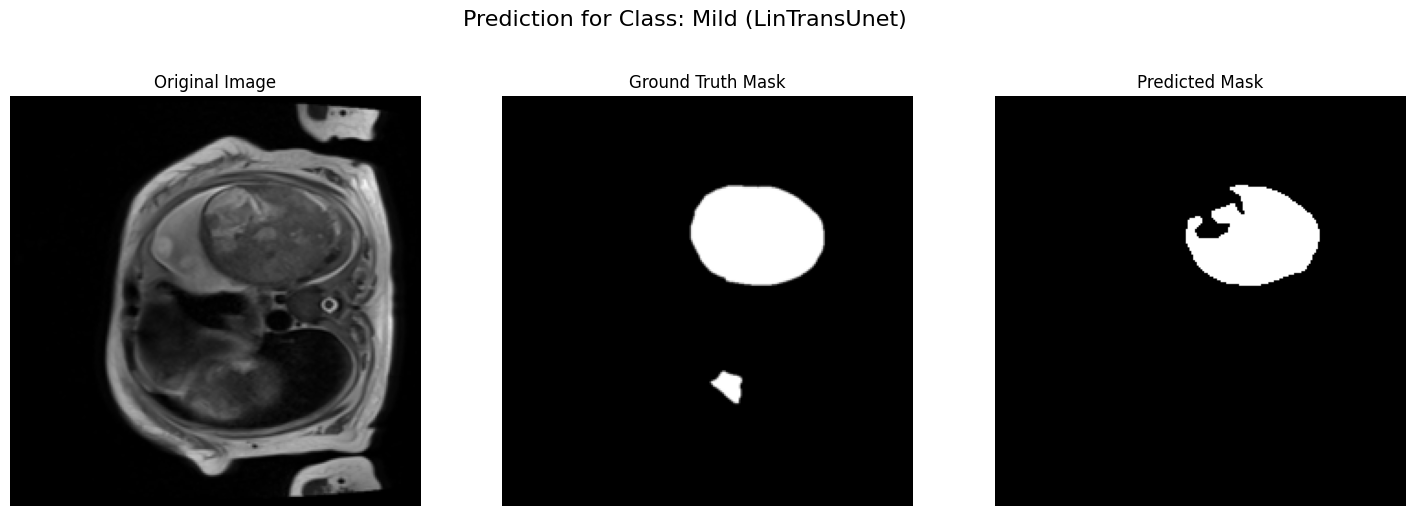

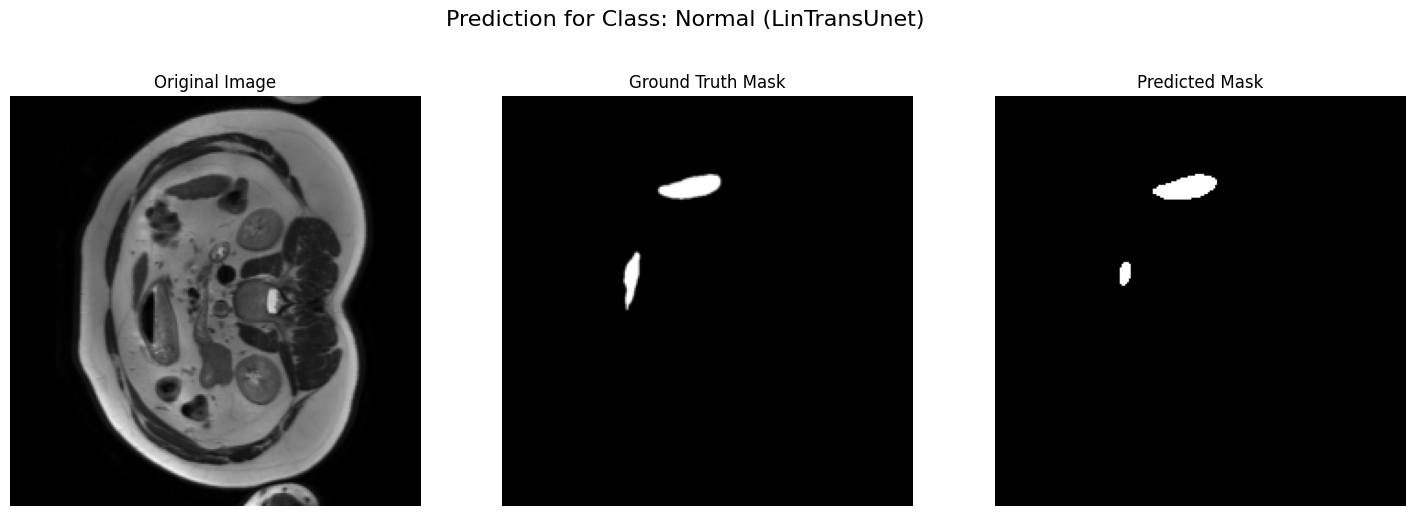

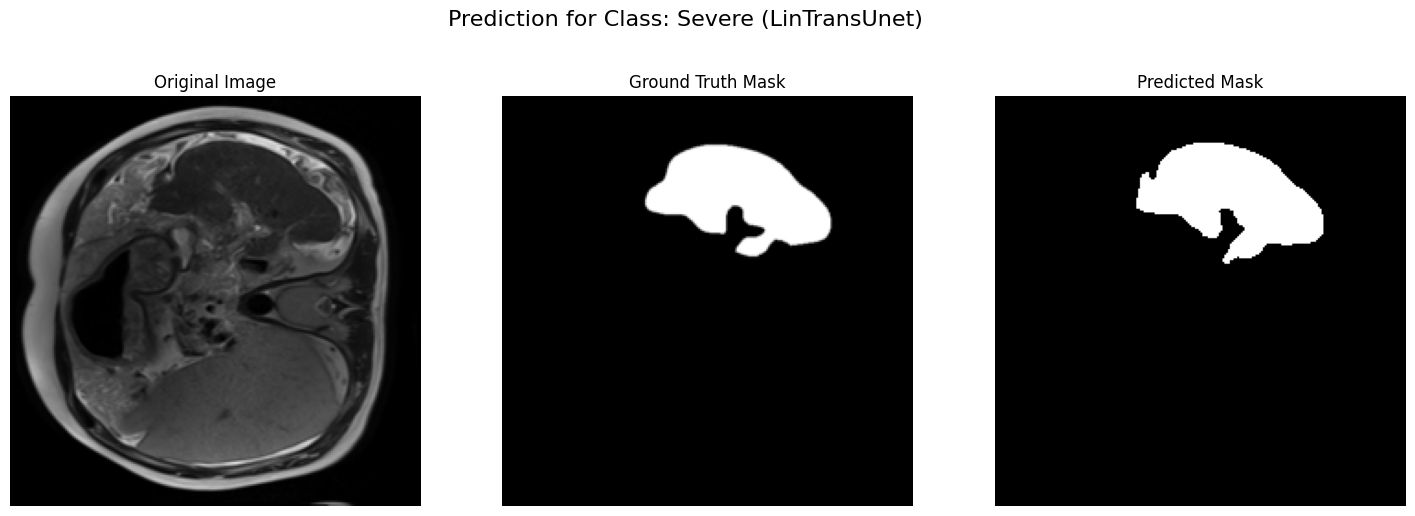


⏱ Total Visualization Time : 1.22 sec

⏱ COMPLETE CODE EXECUTION TIME : 51.90 min


In [10]:
import os
import random
import time
import subprocess
import sys

# --- AUTOMATIC THOP INSTALLATION ---
try:
    from thop import profile
except ImportError:
    print("📦 THOP not found. Installing it automatically via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "thop"])
    from thop import profile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
import torchvision.transforms.functional as F_T
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
from PIL import Image

# --- MONAI Import for Swin UNETR ---
try:
    from monai.networks.nets import SwinUNETR
except ImportError:
    print("MONAI not found. Please install it using: pip install monai einops if using SwinUNETR")
    SwinUNETR = None

# ==========================================
# START OVERALL TIMER
# ==========================================
overall_start_time = time.time()

# --- CONFIGURATION ---
# Choose which model to use: 'LinTransUnet' or 'SwinUNETR'
MODEL_CHOICE = 'LinTransUnet' 

# --- Set Seeds for Reproducibility ---
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# --- Data Loading and Preparation ---
try:
    metadata_df = pd.read_csv('/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv')
    print("Successfully loaded metadata CSV.")
except FileNotFoundError:
    print("Error: Metadata CSV not found. Please ensure the path is correct.")
    metadata_df = pd.DataFrame()

if not metadata_df.empty:
    metadata_df.rename(columns={'Patient ID': 'ID', 'Radiological Evaluation': 'radiological_evaluation'}, inplace=True)
    metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
    metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)
    class_name_map = {1: 'Normal', 2: 'Mild', 3: 'Severe'}
    metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
    metadata_df['class_label'], class_names = pd.factorize(metadata_df['class_name'])
    class_map = {i: name for i, name in enumerate(class_names)}
    print("\n--- Classification Task Setup ---")
    print("Class Mapping for Evaluation:", class_map)
    metadata_df['ID'] = metadata_df['ID'].astype(str)
    valid_ids = set(metadata_df['ID'].tolist())
else:
    valid_ids = set()
    class_map = {}

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        print(f"Warning: Directory '{directory}' not found.")
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

train_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
valid_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
test_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'

train_df = pd.merge(create_dataframe_from_ids(train_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()
val_df = pd.merge(create_dataframe_from_ids(valid_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()
test_df = pd.merge(create_dataframe_from_ids(test_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()

print(f"\nTraining samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset and Transforms ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224), is_train=True):
        self.image_size = image_size
        self.is_train = is_train
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        
    def __call__(self, image, mask):
        image = F_T.resize(image, self.image_size, interpolation=F_T.InterpolationMode.BILINEAR)
        mask = F_T.resize(mask, self.image_size, interpolation=F_T.InterpolationMode.NEAREST)
        if self.is_train and random.random() > 0.5: image, mask = F_T.hflip(image), F_T.hflip(mask)
        image = F_T.to_tensor(image)
        mask = F_T.to_tensor(mask)
        image = F_T.normalize(image, mean=self.mean.flatten(), std=self.std.flatten())
        mask = (mask > 0).float()
        return image, mask

    def denormalize(self, tensor_image):
        return tensor_image * self.std + self.mean

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_file_path']).convert('RGB')
        mask = Image.open(row['mask_file_path']).convert('L')
        class_label = torch.tensor(row['class_label'], dtype=torch.long)
        image, mask = self.transform(image, mask)
        return image, mask, class_label

# --- MODEL DEFINITIONS ---

# Model 1: LinTransUnet
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64):
        super().__init__()
        inner_dim = dim_head * heads
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)
        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: t.view(t.shape[0], -1, self.heads, t.shape[-1] // self.heads).transpose(1, 2), qkv)
        q = q.softmax(dim=-1)
        k = k.softmax(dim=-2)
        q = q * self.scale
        context = torch.einsum('b h n d, b h n e -> b h d e', k, v)
        out = torch.einsum('b h d e, b h n d -> b h n e', context, q)
        out = out.transpose(1, 2).reshape(out.shape[0], -1, self.heads * (out.shape[-1]))
        return self.to_out(out)

class LinTransUnet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        base_layers = list(base_model.children())
        
        self.encoder0 = nn.Sequential(*base_layers[:3]) # 64
        self.encoder1 = nn.Sequential(*base_layers[3:5]) # 256
        self.encoder2 = base_layers[5] # 512
        self.encoder3 = base_layers[6] # 1024
        self.bottleneck = base_layers[7] # 2048

        self.linear_attention = LinearAttention(dim=2048)
        
        self.upconv3 = nn.ConvTranspose2d(2048, 1024, 2, 2)
        self.dec_conv3 = nn.Conv2d(2048, 1024, 3, padding=1)
        self.upconv2 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec_conv2 = nn.Conv2d(1024, 512, 3, padding=1)
        self.upconv1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec_conv1 = nn.Conv2d(512, 256, 3, padding=1)
        self.upconv0 = nn.ConvTranspose2d(256, 64, 2, 2)
        self.dec_conv0 = nn.Conv2d(128, 64, 3, padding=1)
        
        self.final_up = nn.ConvTranspose2d(64, 32, 2, 2)
        self.final_conv = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        e0 = self.encoder0(x)
        e1 = self.encoder1(e0)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        
        b = self.bottleneck(e3)
        bs, c, h, w = b.shape
        b_flat = b.view(bs, c, -1).transpose(1, 2)
        attn_out = self.linear_attention(b_flat)
        b = attn_out.transpose(1, 2).view(bs, c, h, w)
        
        d3 = self.upconv3(b)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = F.relu(self.dec_conv3(d3))
        
        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = F.relu(self.dec_conv2(d2))

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = F.relu(self.dec_conv1(d1))

        d0 = self.upconv0(d1)
        d0 = torch.cat((d0, e0), dim=1)
        d0 = F.relu(self.dec_conv0(d0))
        
        out = self.final_up(d0)
        return self.final_conv(out)

# --- Loss, Metrics, and Training Functions ---
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat, targets_flat = inputs_sig.view(-1), targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        return bce + dice_loss

def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    dice = (2. * intersection + smooth) / (preds_flat.sum() + targets_flat.sum() + smooth)
    return dice.item()

def train_one_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss, total_dice = 0.0, 0.0
    for images, masks, _ in tqdm(loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total_dice += calculate_metrics(outputs, masks) * images.size(0)
    return running_loss / len(loader.dataset), total_dice / len(loader.dataset)

def evaluate_model(loader, model, loss_fn, device, class_mapping):
    model.eval()
    all_preds, all_masks, all_labels = [], [], []
    with torch.no_grad():
        for images, masks, labels in tqdm(loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            all_preds.append(outputs.cpu()); all_masks.append(masks.cpu()); all_labels.append(labels.cpu())
    
    all_preds, all_masks = torch.cat(all_preds), torch.cat(all_masks)
    overall_dice = calculate_metrics(all_preds, all_masks)
    print(f"\n--- Validation Report ---")
    print(f"Overall Dice: {overall_dice:.4f}")
    return overall_dice

# --- FUNCTION FOR PARAMS, FLOPs, LATENCY & FPS PROFILING ---
def profile_model(model, device, input_size=(1, 3, 224, 224)):
    model.eval()
    dummy_input = torch.randn(input_size).to(device)
    
    # 1. Total Parameters (M)
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    
    # 2. FLOPs (G) Calculation using THOP
    try:
        flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
        total_flops = f"{flops / 1e9:.2f} G FLOPs"
    except Exception as e:
        total_flops = "Error during profiling"
        
    # 3. Latency (ms) and Throughput (FPS) Measurement
    for _ in range(20):  # Warm-up cycles
        with torch.no_grad():
            _ = model(dummy_input)
            
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    start_time = time.time()
    runs = 100
    for _ in range(runs):
        with torch.no_grad():
            _ = model(dummy_input)
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    latency_ms = ((time.time() - start_time) / runs) * 1000
    fps = 1000 / latency_ms  # Frames Per Second Formula
    
    print("\n========================================")
    print(f"📊 {MODEL_CHOICE} ARCHITECTURE METRICS:")
    print(f"🔹 Total Parameters : {total_params:.2f} M")
    print(f"🔹 Total Complexity : {total_flops}")
    print(f"🔹 Inference Latency: {latency_ms:.2f} ms")
    print(f"🔹 Throughput (FPS) : {fps:.2f} frames/sec")
    print("========================================\n")

# --- TRAINING EXECUTION ---
# Named uniquely to avoid file overwrite during ensemble setups
MODEL_SAVE_PATH = f'best_{MODEL_CHOICE.lower()}_model.pth'

if not train_df.empty:
    train_transform = SegmentationTransform(is_train=True)
    val_transform = SegmentationTransform(is_train=False)

    train_dataset = LiverDataset(train_df, transform=train_transform)
    val_dataset = LiverDataset(val_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    if MODEL_CHOICE == 'LinTransUnet':
        model = LinTransUnet(n_classes=1).to(device)
        print("\n--- Model Selected: LinTransUnet ---")
    elif MODEL_CHOICE == 'SwinUNETR':
        if SwinUNETR is None:
            raise ImportError("SwinUNETR model requires MONAI. Please install it.")
        model = SwinUNETR(img_size=(224, 224), in_channels=3, out_channels=1, feature_size=48).to(device)
        print("\n--- Model Selected: Swin UNETR ---")
    else:
        raise ValueError("Invalid MODEL_CHOICE. Choose 'LinTransUnet' or 'SwinUNETR'")

    # Run Profiling before training starts
    profile_model(model, device)

    optimizer = AdamW(model.parameters(), lr=1e-4)
    criterion = DiceBCELoss()
    num_epochs = 20
    best_val_dice = 0.0

    print(f"--- Starting Model Training for {MODEL_CHOICE} ---")
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_dice = train_one_epoch(train_loader, model, optimizer, criterion, device)
        print(f"Training -> Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        
        val_dice = evaluate_model(val_loader, model, criterion, device, class_map)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"✅ Model Saved! New Best Dice for {MODEL_CHOICE}: {best_val_dice:.4f} -> Saved as '{MODEL_SAVE_PATH}'")
            
        epoch_time = time.time() - epoch_start_time
        print(f"⏱ Epoch {epoch+1} Time: {epoch_time:.2f} sec ({epoch_time/60:.2f} min)")
        
    training_time = time.time() - training_start_time
    print("\n==============================")
    print(f"⏱ Total Training Time : {training_time:.2f} sec")
    print(f"⏱ Total Training Time : {training_time/60:.2f} min")
    print("==============================")
else:
    print("🛑 Training dataset is empty. Cannot start training.")
    model = None

# --- VISUALIZATION SECTION ---
def visualize_predictions(model, test_df, transforms, device, num_samples_per_class=1):
    if model is None or test_df.empty:
        print("\nSkipping visualization: model not trained or test data is empty.")
        return
        
    print("\n--- Generating Prediction Visualizations ---")
    model.eval()
    
    try:
        model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
        print(f"Best model weights loaded from '{MODEL_SAVE_PATH}' for visualization.")
    except (FileNotFoundError, RuntimeError) as e:
        print(f"Could not load best weights ({e}). Visualizing with last epoch's model.")

    grouped = test_df.groupby('class_name')
    for class_name, group in grouped:
        samples = group.sample(min(len(group), num_samples_per_class))
        for _, row in samples.iterrows():
            original_image = Image.open(row['image_file_path']).convert('RGB')
            original_mask = Image.open(row['mask_file_path']).convert('L')

            input_tensor, _ = transforms(original_image, original_mask)
            input_tensor = input_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                pred_logits = model(input_tensor)
                pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze(0)

            display_image = transforms.denormalize(input_tensor.cpu().squeeze(0))
            display_image = display_image.permute(1, 2, 0).numpy()
            display_mask = F_T.resize(original_mask, (224, 224))

            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f"Prediction for Class: {class_name} ({MODEL_CHOICE})", fontsize=16)
            axes[0].imshow(display_image); axes[0].set_title("Original Image"); axes[0].axis('off')
            axes[1].imshow(display_mask, cmap='gray'); axes[1].set_title("Ground Truth Mask"); axes[1].axis('off')
            axes[2].imshow(pred_mask.squeeze(), cmap='gray'); axes[2].set_title("Predicted Mask"); axes[2].axis('off')
            plt.show()

if model:
    viz_start_time = time.time()
    visualize_predictions(model, test_df, val_transform, device, num_samples_per_class=1)
    viz_time = time.time() - viz_start_time
    print(f"\n⏱ Total Visualization Time : {viz_time:.2f} sec")

# ==========================================
# END OVERALL TIMER & PRINT REPORT
# ==========================================
overall_time = time.time() - overall_start_time
print("\n========================================")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/60:.2f} min")
print("========================================")

U²-Net and VGG16

In [11]:
!pip install transformers

In [13]:
import os
import random
import time
import subprocess
import sys

# --- AUTOMATIC THOP INSTALLATION ---
try:
    from thop import profile
except ImportError:
    print("📦 THOP not found. Installing it automatically via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "thop"])
    from thop import profile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
import torchvision.transforms.functional as F_T
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
from PIL import Image

# --- Imports for LIME ---
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ==========================================
# START OVERALL TIMER
# ==========================================
overall_start_time = time.time()

# --- Set Seeds for Reproducibility ---
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Set CUDA_LAUNCH_BLOCKING for easier debugging
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# --- Data Loading and Preparation (Using exact paths from previous prompt) ---
try:
    metadata_df = pd.read_csv('/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv')
    print("Successfully loaded metadata CSV.")
except FileNotFoundError:
    print("Warning: Path 1 failed, trying fallback path...")
    try:
        metadata_df = pd.read_csv('/kaggle/input/t2metadata/T2_age_gender_evaluation.csv')
        print("Successfully loaded metadata CSV from fallback path.")
    except FileNotFoundError:
        print("Error: Metadata CSV not found. Initializing empty DataFrame.")
        metadata_df = pd.DataFrame()

if not metadata_df.empty:
    # Rename and process columns
    metadata_df.rename(columns={
        'Patient ID': 'ID',
        'Radiological Evaluation': 'radiological_evaluation'
    }, inplace=True)
    metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
    metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)

    # Map numerical classes to names
    class_name_map = {1: 'Normal', 2: 'Mild', 3: 'Severe'}
    metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
    metadata_df['class_label'], class_names = pd.factorize(metadata_df['class_name'])
    class_map = {i: name for i, name in enumerate(class_names)}

    print("\n--- Classification Task Setup ---")
    print("Class Mapping for Evaluation:", class_map)

    metadata_df['ID'] = metadata_df['ID'].astype(str)
    valid_ids = set(metadata_df['ID'].tolist())
else:
    valid_ids = set()
    class_map = {}

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        print(f"Warning: Directory '{directory}' not found. Skipping.")
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

# Dataset Base Directories (Checking standard dataset layouts mentioned previously)
train_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
valid_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
test_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'

if not os.path.exists(train_dir):
    # Fallback to direct input paths
    train_dir = '/kaggle/input/datat2/Cirrhosis_T2_2D/train'
    valid_dir = '/kaggle/input/datat2/Cirrhosis_T2_2D/valid'
    test_dir = '/kaggle/input/datat2/Cirrhosis_T2_2D/test'

train_df = pd.merge(create_dataframe_from_ids(train_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()
val_df = pd.merge(create_dataframe_from_ids(valid_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()
test_df = pd.merge(create_dataframe_from_ids(test_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()

print(f"\nTraining samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset and Transforms ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224), is_train=True):
        self.image_size = image_size
        self.is_train = is_train
    def __call__(self, image, mask):
        image = F_T.resize(image, self.image_size, interpolation=F_T.InterpolationMode.BILINEAR)
        mask = F_T.resize(mask, self.image_size, interpolation=F_T.InterpolationMode.NEAREST)
        if self.is_train:
            if random.random() > 0.5: image, mask = F_T.hflip(image), F_T.hflip(mask)
            if random.random() > 0.5: image, mask = F_T.vflip(image), F_T.vflip(mask)
            angle = random.uniform(-15, 15)
            image, mask = F_T.rotate(image, angle), F_T.rotate(mask, angle)
        image = F_T.to_tensor(image)
        mask = F_T.to_tensor(mask)
        image = F_T.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = (mask > 0).float()
        return image, mask

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_file_path']).convert('RGB')
        mask = Image.open(row['mask_file_path']).convert('L')
        class_label = torch.tensor(row['class_label'], dtype=torch.long)
        if self.transform:
            image, mask = self.transform(image, mask)
        return image, mask, class_label

# --- U²-Net Model with VGG16-style Encoder ---
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True)
    )

class RSU7(nn.Module): 
    def __init__(self, in_ch, mid_ch, out_ch):
        super().__init__()
        self.conv_in = conv_block(in_ch, out_ch)
        self.e1 = conv_block(out_ch, mid_ch)
        self.pool1 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.e2 = conv_block(mid_ch, mid_ch)
        self.pool2 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.e3 = conv_block(mid_ch, mid_ch)
        self.pool3 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.e4 = conv_block(mid_ch, mid_ch)
        self.pool4 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.e5 = conv_block(mid_ch, mid_ch)
        self.pool5 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.e6 = conv_block(mid_ch, mid_ch)
        self.e7 = conv_block(mid_ch, mid_ch) 
        self.d6 = conv_block(mid_ch * 2, mid_ch)
        self.d5 = conv_block(mid_ch * 2, mid_ch)
        self.d4 = conv_block(mid_ch * 2, mid_ch)
        self.d3 = conv_block(mid_ch * 2, mid_ch)
        self.d2 = conv_block(mid_ch * 2, mid_ch)
        self.d1 = conv_block(mid_ch * 2, out_ch)

    def forward(self, x):
        xi = self.conv_in(x)
        e1 = self.e1(xi)
        e2 = self.e2(self.pool1(e1))
        e3 = self.e3(self.pool2(e2))
        e4 = self.e4(self.pool3(e3))
        e5 = self.e5(self.pool4(e4))
        e6 = self.e6(self.pool5(e5))
        e7 = self.e7(e6)
        
        d6 = self.d6(torch.cat((e7, e6), 1))
        d5 = self.d5(torch.cat((F.interpolate(d6, size=e5.size()[2:], mode='bilinear', align_corners=True), e5), 1))
        d4 = self.d4(torch.cat((F.interpolate(d5, size=e4.size()[2:], mode='bilinear', align_corners=True), e4), 1))
        d3 = self.d3(torch.cat((F.interpolate(d4, size=e3.size()[2:], mode='bilinear', align_corners=True), e3), 1))
        d2 = self.d2(torch.cat((F.interpolate(d3, size=e2.size()[2:], mode='bilinear', align_corners=True), e2), 1))
        d1 = self.d1(torch.cat((F.interpolate(d2, size=e1.size()[2:], mode='bilinear', align_corners=True), e1), 1))
        return d1 + xi

class RSU4F(nn.Module): 
    def __init__(self, in_ch, mid_ch, out_ch):
        super().__init__()
        self.conv_in = conv_block(in_ch, out_ch)
        self.e1 = conv_block(out_ch, mid_ch)
        self.e2 = conv_block(mid_ch, mid_ch)
        self.e3 = conv_block(mid_ch, mid_ch)
        self.e4 = conv_block(mid_ch, mid_ch) 
        self.d3 = conv_block(mid_ch * 2, mid_ch)
        self.d2 = conv_block(mid_ch * 2, mid_ch)
        self.d1 = conv_block(mid_ch * 2, out_ch)

    def forward(self, x):
        xi = self.conv_in(x)
        e1 = self.e1(xi)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        
        d3 = self.d3(torch.cat((e4, e3), 1))
        d2 = self.d2(torch.cat((d3, e2), 1))
        d1 = self.d1(torch.cat((d2, e1), 1))
        return d1 + xi

class U2Net_VGG16(nn.Module):
    def __init__(self, in_channels=3, n_classes=1):
        super().__init__()
        
        self.stage1 = RSU7(in_channels, 32, 64)
        self.pool1 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.stage2 = RSU7(64, 32, 128)
        self.pool2 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.stage3 = RSU7(128, 64, 256)
        self.pool3 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.stage4 = RSU4F(256, 128, 512)
        self.pool4 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.stage5 = RSU4F(512, 256, 512)
        self.pool5 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.stage6 = RSU4F(512, 256, 512) 

        self.stage5d = RSU4F(1024, 256, 512)
        self.stage4d = RSU4F(1024, 128, 256)
        self.stage3d = RSU7(512, 64, 128)
        self.stage2d = RSU7(256, 32, 64)
        self.stage1d = RSU7(128, 16, 64)

        self.side1 = nn.Conv2d(64, n_classes, 3, padding=1)
        self.side2 = nn.Conv2d(64, n_classes, 3, padding=1)
        self.side3 = nn.Conv2d(128, n_classes, 3, padding=1)
        self.side4 = nn.Conv2d(256, n_classes, 3, padding=1)
        self.side5 = nn.Conv2d(512, n_classes, 3, padding=1)
        self.side6 = nn.Conv2d(512, n_classes, 3, padding=1)
        self.outconv = nn.Conv2d(6 * n_classes, n_classes, 1)

    def forward(self, x):
        hx1 = self.stage1(x)
        hx = self.pool1(hx1)
        hx2 = self.stage2(hx)
        hx = self.pool2(hx2)
        hx3 = self.stage3(hx)
        hx = self.pool3(hx3)
        hx4 = self.stage4(hx)
        hx = self.pool4(hx4)
        hx5 = self.stage5(hx)
        hx = self.pool5(hx5)
        hx6 = self.stage6(hx)
        
        hx6up = F.interpolate(hx6, size=hx5.size()[2:], mode='bilinear', align_corners=True)
        
        hx5d = self.stage5d(torch.cat((hx6up, hx5), 1))
        hx5dup = F.interpolate(hx5d, size=hx4.size()[2:], mode='bilinear', align_corners=True)
        hx4d = self.stage4d(torch.cat((hx5dup, hx4), 1))
        hx4dup = F.interpolate(hx4d, size=hx3.size()[2:], mode='bilinear', align_corners=True)
        hx3d = self.stage3d(torch.cat((hx4dup, hx3), 1))
        hx3dup = F.interpolate(hx3d, size=hx2.size()[2:], mode='bilinear', align_corners=True)
        hx2d = self.stage2d(torch.cat((hx3dup, hx2), 1))
        hx2dup = F.interpolate(hx2d, size=hx1.size()[2:], mode='bilinear', align_corners=True)
        hx1d = self.stage1d(torch.cat((hx2dup, hx1), 1))

        d1 = self.side1(hx1d)
        d2 = self.side2(hx2d)
        d3 = self.side3(hx3d)
        d4 = self.side4(hx4d)
        d5 = self.side5(hx5d)
        d6 = self.side6(hx6)
        
        d1 = F.interpolate(d1, size=x.size()[2:], mode='bilinear', align_corners=True)
        d2 = F.interpolate(d2, size=x.size()[2:], mode='bilinear', align_corners=True)
        d3 = F.interpolate(d3, size=x.size()[2:], mode='bilinear', align_corners=True)
        d4 = F.interpolate(d4, size=x.size()[2:], mode='bilinear', align_corners=True)
        d5 = F.interpolate(d5, size=x.size()[2:], mode='bilinear', align_corners=True)
        d6 = F.interpolate(d6, size=x.size()[2:], mode='bilinear', align_corners=True)

        d0 = self.outconv(torch.cat((d1, d2, d3, d4, d5, d6), 1))
        return [d0, d1, d2, d3, d4, d5, d6]

# --- Loss, Metrics, and Training Functions ---
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        return bce + dice_loss

def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

def train_one_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    for images, masks, _ in tqdm(loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = sum(loss_fn(o, masks) for o in outputs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        dice, iou = calculate_metrics(outputs[0], masks)
        total_dice += dice * images.size(0)
        total_iou += iou * images.size(0)
    return (running_loss / len(loader.dataset),
            total_dice / len(loader.dataset),
            total_iou / len(loader.dataset))

def evaluate_model(loader, model, loss_fn, device, class_mapping, dataset_name="Validation"):
    model.eval()
    all_preds, all_masks, all_labels = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, masks, labels in tqdm(loader, desc=f"Evaluating on {dataset_name}"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = sum(loss_fn(o, masks) for o in outputs)
            running_loss += loss.item() * images.size(0)
            all_preds.append(outputs[0].cpu())
            all_masks.append(masks.cpu())
            all_labels.append(labels.cpu())

    if len(all_preds) == 0:
        return 0.0, 0.0

    all_preds, all_masks, all_labels = torch.cat(all_preds), torch.cat(all_masks), torch.cat(all_labels)
    avg_loss = running_loss / len(loader.dataset)
    overall_dice, overall_iou = calculate_metrics(all_preds, all_masks)
    print(f"\n--- {dataset_name} Report ---")
    print(f"Overall -> Loss: {avg_loss:.4f}, Dice: {overall_dice:.4f}, mIoU: {overall_iou:.4f}")
    
    print("--- Per-Class Metrics ---")
    for class_idx, class_name in class_mapping.items():
        indices = (all_labels == class_idx).nonzero(as_tuple=True)[0]
        if len(indices) > 0:
            class_dice, class_iou = calculate_metrics(all_preds[indices], all_masks[indices])
            print(f"Class '{class_name}' ({len(indices)} samples) -> Dice: {class_dice:.4f}, mIoU: {class_iou:.4f}")
    return avg_loss, overall_dice

# --- PARAMS, FLOPs, LATENCY & FPS PROFILING FUNCTION ---
def profile_model(model, device, input_size=(1, 3, 224, 224)):
    model.eval()
    dummy_input = torch.randn(input_size).to(device)
    
    # 1. Parameters (M)
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    
    # 2. Complexity / FLOPs (G)
    try:
        flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
        total_flops = f"{flops / 1e9:.2f} G FLOPs"
    except Exception as e:
        total_flops = "Error during profiling"
        
    # 3. Latency & FPS
    for _ in range(20):  # Warm-up
        with torch.no_grad():
            _ = model(dummy_input)
            
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    start_time = time.time()
    runs = 100
    for _ in range(runs):
        with torch.no_grad():
            _ = model(dummy_input)
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    latency_ms = ((time.time() - start_time) / runs) * 1000
    fps = 1000 / latency_ms
    
    print("\n========================================")
    print("📊 U2Net_VGG16 ARCHITECTURE METRICS:")
    print(f"🔹 Total Parameters : {total_params:.2f} M")
    print(f"🔹 Total Complexity : {total_flops}")
    print(f"🔹 Inference Latency: {latency_ms:.2f} ms")
    print(f"🔹 Throughput (FPS) : {fps:.2f} frames/sec")
    print("========================================\n")

# --- FULL TRAINING LOOP ---
MODEL_SAVE_PATH = 'best_u2net_vgg16_model.pth'

if len(train_df) > 0:
    train_dataset = LiverDataset(train_df, transform=SegmentationTransform(is_train=True))
    val_dataset = LiverDataset(val_df, transform=SegmentationTransform(is_train=False))
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    # Instantiate and Profile Model
    model = U2Net_VGG16(in_channels=3, n_classes=1).to(device)
    profile_model(model, device)

    optimizer = AdamW(model.parameters(), lr=1e-4)
    criterion = DiceBCELoss()
    num_epochs = 20 
    best_val_dice = 0.0

    print("\n--- Starting Model Training with U²-Net (VGG16-Style Encoder) ---")
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss, train_dice, _ = train_one_epoch(train_loader, model, optimizer, criterion, device)
        print(f"Training -> Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        
        val_loss, val_dice = evaluate_model(val_loader, model, criterion, device, class_map)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"✅ Model Saved! New Best Dice: {best_val_dice:.4f} -> Saved as '{MODEL_SAVE_PATH}'")
            
        epoch_time = time.time() - epoch_start_time
        print(f"⏱ Epoch {epoch+1} Time: {epoch_time:.2f} sec ({epoch_time/60:.2f} min)")
        
    training_time = time.time() - training_start_time
    print("\n==============================")
    print(f"⏱ Total Training Time : {training_time:.2f} sec")
    print(f"⏱ Total Training Time : {training_time/60:.2f} min")
    print("==============================")
else:
    print("🛑 Dataset configuration is empty. Instantiating model for LIME/Profiling only.")
    model = U2Net_VGG16(in_channels=3, n_classes=1).to(device)
    profile_model(model, device)

# --- LIME EXPLANATION SECTION ---
print("\n--- Loading Best Model for LIME Explanation ---")
try:
    model = U2Net_VGG16(in_channels=3, n_classes=1).to(device)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print(f"Best U²-Net model weights loaded successfully from '{MODEL_SAVE_PATH}' for LIME.")
except FileNotFoundError:
    print(f"Model file '{MODEL_SAVE_PATH}' not found. Using current weights for LIME explanation.")

def get_pil_transform():
    return transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def get_preprocess_transform():
    return transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def batch_predict(images):
    """Prediction function for LIME, adapted for U²-Net."""
    model.eval()
    batch = torch.stack([get_preprocess_transform()(image) for image in images], dim=0).to(device).float()
    with torch.no_grad():
        logits = model(batch)[0] 
    probs = torch.sigmoid(logits)
    segmentation_confidence = probs.sum(dim=[1, 2, 3])
    return torch.stack([1 - segmentation_confidence, segmentation_confidence], dim=1).cpu().numpy()

def generate_lime_explanation(dataset, model, class_mapping):
    if model is None or len(dataset) == 0:
        print("Skipping LIME: model or dataset not available.")
        return

    print("\n--- Generating LIME Explanations for Each Class ---")
    explainer = lime_image.LimeImageExplainer()
    test_df_viz = dataset.dataframe.drop_duplicates(subset=['class_label'])

    for _, row in test_df_viz.iterrows():
        class_name = row['class_name']
        image_path = row['image_file_path']
        original_image = Image.open(image_path).convert('RGB').resize((224, 224))
        
        print(f"\nExplaining a sample for class: '{class_name}'...")
        explanation = explainer.explain_instance(np.array(original_image), batch_predict, top_labels=1, hide_color=0, num_samples=1000)
        
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
        
        img_tensor = get_pil_transform()(original_image).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_mask = (torch.sigmoid(model(img_tensor)[0]) > 0.5).float().cpu().squeeze(0).permute(1, 2, 0)
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"LIME Explanation for Class: {class_name}", fontsize=16)
        axes[0].imshow(original_image); axes[0].set_title("Original Image"); axes[0].axis('off')
        axes[1].imshow(pred_mask, cmap='gray'); axes[1].set_title("Model's Predicted Mask"); axes[1].axis('off')
        axes[2].imshow(mark_boundaries(temp / 2 + 0.5, mask)); axes[2].set_title("LIME: Important Regions"); axes[2].axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# Run LIME on the test dataset
if len(test_df) > 0:
    test_dataset = LiverDataset(test_df, transform=None) 
    generate_lime_explanation(test_dataset, model, class_map)
else:
    print("🛑 Test DataFrame is empty, skipping LIME visualization.")

# ==========================================
# END OVERALL TIMER & PRINT REPORT
# ==========================================
overall_time = time.time() - overall_start_time
print("\n========================================")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/60:.2f} min")
print("========================================")

Using device: cuda ⚙️
Successfully loaded metadata CSV.

--- Classification Task Setup ---
Class Mapping for Evaluation: {0: 'Severe', 1: 'Normal', 2: 'Mild'}

Training samples: 5364, Validation samples: 674, Test samples: 664

📊 U2Net_VGG16 ARCHITECTURE METRICS:
🔹 Total Parameters : 44.49 M
🔹 Total Complexity : 30.22 G FLOPs
🔹 Inference Latency: 40.74 ms
🔹 Throughput (FPS) : 24.54 frames/sec


--- Starting Model Training with U²-Net (VGG16-Style Encoder) ---

Epoch 1/20


Training: 100%|██████████| 336/336 [04:47<00:00,  1.17it/s]


Training -> Loss: 4.1154, Dice: 0.4294


Evaluating on Validation: 100%|██████████| 43/43 [00:11<00:00,  3.69it/s]



--- Validation Report ---
Overall -> Loss: 2.5603, Dice: 0.7592, mIoU: 0.6118
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.6509, mIoU: 0.4825
Class 'Normal' (309 samples) -> Dice: 0.8045, mIoU: 0.6729
Class 'Mild' (189 samples) -> Dice: 0.7639, mIoU: 0.6180
✅ Model Saved! New Best Dice: 0.7592 -> Saved as 'best_u2net_vgg16_model.pth'
⏱ Epoch 1 Time: 300.43 sec (5.01 min)

Epoch 2/20


...

Training: 100%|██████████| 336/336 [04:47<00:00,  1.17it/s]


Training -> Loss: 0.8485, Dice: 0.9370


Evaluating on Validation: 100%|██████████| 43/43 [00:11<00:00,  3.66it/s]



--- Validation Report ---
Overall -> Loss: 1.0277, Dice: 0.9264, mIoU: 0.8630
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.8811, mIoU: 0.7874
Class 'Normal' (309 samples) -> Dice: 0.9380, mIoU: 0.8833
Class 'Mild' (189 samples) -> Dice: 0.9354, mIoU: 0.8786
⏱ Epoch 20 Time: 300.12 sec (5.00 min)

⏱ Total Training Time : 6006.59 sec
⏱ Total Training Time : 100.11 min

--- Loading Best Model for LIME Explanation ---


RuntimeError: Error(s) in loading state_dict for U2Net_VGG16:
	Unexpected key(s) in state_dict: "total_ops", "total_params", "stage1.total_ops", "stage1.total_params", "stage2.total_ops", "stage2.total_params", "stage3.total_ops", "stage3.total_params", "stage4.total_ops", "stage4.total_params", "stage5.total_ops", "stage5.total_params", "stage6.total_ops", "stage6.total_params", "stage5d.total_ops", "stage5d.total_params", "stage4d.total_ops", "stage4d.total_params", "stage3d.total_ops", "stage3d.total_params", "stage2d.total_ops", "stage2d.total_params", "stage1d.total_ops", "stage1d.total_params". 

In [14]:
import os
import random
import time
import subprocess
import sys

# --- AUTOMATIC THOP INSTALLATION ---
try:
    from thop import profile
except ImportError:
    print("📦 THOP not found. Installing it automatically via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "thop"])
    from thop import profile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
import torchvision.transforms.functional as F_T
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
from PIL import Image
from scipy.ndimage import binary_erosion

# --- Imports for LIME ---
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ==========================================
# START OVERALL TIMER
# ==========================================
overall_start_time = time.time()

# --- Set Seeds for Reproducibility ---
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Set CUDA_LAUNCH_BLOCKING for easier debugging
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# --- Data Loading and Preparation (Robust Paths) ---
try:
    metadata_df = pd.read_csv('/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv')
    print("Successfully loaded metadata CSV from primary path.")
except FileNotFoundError:
    print("Warning: Primary metadata path failed, trying fallback path...")
    try:
        metadata_df = pd.read_csv('/kaggle/input/t2metadata/T2_age_gender_evaluation.csv')
        print("Successfully loaded metadata CSV from fallback path.")
    except FileNotFoundError:
        print("Error: Metadata CSV not found. Initializing empty DataFrame.")
        metadata_df = pd.DataFrame()

if not metadata_df.empty:
    # Rename and process columns
    metadata_df.rename(columns={
        'Patient ID': 'ID',
        'Radiological Evaluation': 'radiological_evaluation'
    }, inplace=True)
    metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
    metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)

    # Map numerical classes to names
    class_name_map = {1: 'Normal', 2: 'Mild', 3: 'Severe'}
    metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
    metadata_df['class_label'], class_names = pd.factorize(metadata_df['class_name'])
    class_map = {i: name for i, name in enumerate(class_names)}

    print("\n--- Classification Task Setup ---")
    print("Class Mapping for Evaluation:", class_map)

    metadata_df['ID'] = metadata_df['ID'].astype(str)
    valid_ids = set(metadata_df['ID'].tolist())
else:
    valid_ids = set()
    class_map = {}

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        print(f"Warning: Directory '{directory}' not found. Skipping.")
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

# Dataset Base Directories
train_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
valid_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
test_dir = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'

if not os.path.exists(train_dir):
    train_dir = '/kaggle/input/datat2/Cirrhosis_T2_2D/train'
    valid_dir = '/kaggle/input/datat2/Cirrhosis_T2_2D/valid'
    test_dir = '/kaggle/input/datat2/Cirrhosis_T2_2D/test'

train_df = pd.merge(create_dataframe_from_ids(train_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()
val_df = pd.merge(create_dataframe_from_ids(valid_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()
test_df = pd.merge(create_dataframe_from_ids(test_dir, valid_ids), metadata_df, on='ID') if not metadata_df.empty else pd.DataFrame()

print(f"\nTraining samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset and Transforms (Optimized for InceptionV3 299x299) ---
class SegmentationTransform:
    def __init__(self, image_size=(299, 299), is_train=True):
        self.image_size = image_size
        self.is_train = is_train
    def __call__(self, image, mask):
        image = F_T.resize(image, self.image_size, interpolation=F_T.InterpolationMode.BILINEAR)
        mask = F_T.resize(mask, self.image_size, interpolation=F_T.InterpolationMode.NEAREST)
        if self.is_train:
            if random.random() > 0.5: image, mask = F_T.hflip(image), F_T.hflip(mask)
            if random.random() > 0.5: image, mask = F_T.vflip(image), F_T.vflip(mask)
            angle = random.uniform(-15, 15)
            image, mask = F_T.rotate(image, angle), F_T.rotate(mask, angle)
        image = F_T.to_tensor(image)
        mask = F_T.to_tensor(mask)
        image = F_T.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = (mask > 0).float()
        return image, mask

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_file_path']).convert('RGB')
        mask_pil = Image.open(row['mask_file_path']).convert('L')
        class_label = torch.tensor(row['class_label'], dtype=torch.long)
        
        if self.transform:
            image, mask = self.transform(mask_pil if image is None else image, mask_pil)
        else:
            image = F_T.to_tensor(image)
            mask = F_T.to_tensor(mask_pil)
            mask = (mask > 0).float()
            
        # Generate boundary mask from the main mask
        mask_numpy = mask.squeeze().cpu().numpy()
        eroded_mask = binary_erosion(mask_numpy, iterations=1)
        boundary = torch.from_numpy(mask_numpy - eroded_mask).unsqueeze(0).float()
        
        return image, mask, boundary, class_label

# --- SynergyNet Model Architecture with InceptionV3 Encoder ---
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels + skip_channels, out_channels)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class FeatureSynergyModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.synergy_conv = nn.Sequential(
            nn.Conv2d(channels * 2, channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, f_main, f_aux):
        f_cat = torch.cat([f_main, f_aux], dim=1)
        f_syn = self.synergy_conv(f_cat)
        f_main_out = f_main + f_syn
        f_aux_out = f_aux + f_syn
        return f_main_out, f_aux_out

class SynergyNetInceptionV3(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        
        # Encoder stages
        self.enc0 = nn.Sequential(inception.Conv2d_1a_3x3, inception.Conv2d_2a_3x3, inception.Conv2d_2b_3x3, nn.MaxPool2d(kernel_size=3, stride=2)) 
        self.enc1 = nn.Sequential(inception.Conv2d_3b_1x1, inception.Conv2d_4a_3x3, nn.MaxPool2d(kernel_size=3, stride=2)) 
        self.enc2 = nn.Sequential(inception.Mixed_5b, inception.Mixed_5c, inception.Mixed_5d) 
        self.enc3 = nn.Sequential(inception.Mixed_6a, inception.Mixed_6b, inception.Mixed_6c, inception.Mixed_6d, inception.Mixed_6e) 
        self.bottleneck = nn.Sequential(inception.Mixed_7a, inception.Mixed_7b, inception.Mixed_7c) 
        
        # Decoder for Main Mask
        self.dec_main3 = DecoderBlock(2048, 768, 512)
        self.dec_main2 = DecoderBlock(512, 288, 256)
        self.dec_main1 = DecoderBlock(256, 192, 128)
        self.dec_main0 = DecoderBlock(128, 64, 64)

        # Decoder for Auxiliary Boundary
        self.dec_aux3 = DecoderBlock(2048, 768, 512)
        self.dec_aux2 = DecoderBlock(512, 288, 256)
        self.dec_aux1 = DecoderBlock(256, 192, 128)
        self.dec_aux0 = DecoderBlock(128, 64, 64)

        # Feature Synergy Modules
        self.fsm2 = FeatureSynergyModule(256)
        self.fsm1 = FeatureSynergyModule(128)
        self.fsm0 = FeatureSynergyModule(64)
        
        # Output layers
        self.out_main = nn.Conv2d(64, n_classes, kernel_size=1)
        self.out_aux = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(e0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b = self.bottleneck(e3)
        
        d_main3 = self.dec_main3(b, e3)
        d_aux3 = self.dec_aux3(b, e3)
        
        d_main2 = self.dec_main2(d_main3, e2)
        d_aux2 = self.dec_aux2(d_aux3, e2)
        d_main2, d_aux2 = self.fsm2(d_main2, d_aux2)
        
        d_main1 = self.dec_main1(d_main2, e1)
        d_aux1 = self.dec_aux1(d_aux2, e1)
        d_main1, d_aux1 = self.fsm1(d_main1, d_aux1)
        
        d_main0 = self.dec_main0(d_main1, e0)
        d_aux0 = self.dec_aux0(d_aux1, e0)
        d_main0, d_aux0 = self.fsm0(d_main0, d_aux0)
        
        out_main = F.interpolate(d_main0, size=x.shape[2:], mode='bilinear', align_corners=True)
        out_aux = F.interpolate(d_aux0, size=x.shape[2:], mode='bilinear', align_corners=True)
        
        return self.out_main(out_main), self.out_aux(out_aux)

# --- Loss, Metrics, and Training Functions ---
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        return bce + dice_loss

def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

def train_one_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    for images, masks, boundaries, _ in tqdm(loader, desc="Training"):
        images, masks, boundaries = images.to(device), masks.to(device), boundaries.to(device)
        
        optimizer.zero_grad()
        pred_masks, pred_boundaries = model(images)
        
        loss_mask = loss_fn(pred_masks, masks)
        loss_boundary = loss_fn(pred_boundaries, boundaries)
        loss = loss_mask + loss_boundary
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        
        dice, iou = calculate_metrics(pred_masks, masks)
        total_dice += dice * images.size(0)
        total_iou += iou * images.size(0)
        
    return (running_loss / len(loader.dataset),
            total_dice / len(loader.dataset),
            total_iou / len(loader.dataset))

def evaluate_model(loader, model, loss_fn, device, class_mapping, dataset_name="Validation"):
    model.eval()
    all_preds, all_masks, all_labels = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, masks, boundaries, labels in tqdm(loader, desc=f"Evaluating on {dataset_name}"):
            images, masks, boundaries = images.to(device), masks.to(device), boundaries.to(device)
            pred_masks, pred_boundaries = model(images)
            
            loss_mask = loss_fn(pred_masks, masks)
            loss_boundary = loss_fn(pred_boundaries, boundaries)
            loss = loss_mask + loss_boundary
            running_loss += loss.item() * images.size(0)
            
            all_preds.append(pred_masks.cpu())
            all_masks.append(masks.cpu())
            all_labels.append(labels.cpu())

    if len(all_preds) == 0:
        return 0.0, 0.0

    all_preds, all_masks, all_labels = torch.cat(all_preds), torch.cat(all_masks), torch.cat(all_labels)
    avg_loss = running_loss / len(loader.dataset)
    overall_dice, overall_iou = calculate_metrics(all_preds, all_masks)
    print(f"\n--- {dataset_name} Report ---")
    print(f"Overall -> Loss: {avg_loss:.4f}, Dice: {overall_dice:.4f}, mIoU: {overall_iou:.4f}")
    
    print("--- Per-Class Metrics ---")
    for class_idx, class_name in class_mapping.items():
        indices = (all_labels == class_idx).nonzero(as_tuple=True)[0]
        if len(indices) > 0:
            class_dice, class_iou = calculate_metrics(all_preds[indices], all_masks[indices])
            print(f"Class '{class_name}' ({len(indices)} samples) -> Dice: {class_dice:.4f}, mIoU: {class_iou:.4f}")
    return avg_loss, overall_dice

# --- PARAMS, FLOPs, LATENCY & FPS PROFILING FUNCTION ---
def profile_model(model, device, input_size=(1, 3, 299, 299)):
    model.eval()
    dummy_input = torch.randn(input_size).to(device)
    
    # 1. Calculate Parameters (M)
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    
    # 2. Calculate Complexity / FLOPs (G) using THOP
    try:
        flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
        total_flops = f"{flops / 1e9:.2f} G FLOPs"
    except Exception as e:
        total_flops = "Error during profiling"
        
    # 3. Calculate Latency & FPS
    for _ in range(20):  # Warm-up iterations
        with torch.no_grad():
            _ = model(dummy_input)
            
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    start_time = time.time()
    runs = 100
    for _ in range(runs):
        with torch.no_grad():
            _ = model(dummy_input)
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    latency_ms = ((time.time() - start_time) / runs) * 1000
    fps = 1000 / latency_ms
    
    print("\n========================================")
    print("📊 SYNERGYNET_INCEPTIONV3 ARCHITECTURE METRICS:")
    print(f"🔹 Total Parameters : {total_params:.2f} M")
    print(f"🔹 Total Complexity : {total_flops}")
    print(f"🔹 Inference Latency: {latency_ms:.2f} ms")
    print(f"🔹 Throughput (FPS) : {fps:.2f} frames/sec")
    print("========================================\n")

# --- FULL TRAINING LOOP ---
MODEL_SAVE_PATH = 'best_synergynet_inceptionv3_model.pth'

if len(train_df) > 0:
    train_dataset = LiverDataset(train_df, transform=SegmentationTransform(is_train=True))
    val_dataset = LiverDataset(val_df, transform=SegmentationTransform(is_train=False))
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True) 
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

    # Instantiate and Profile Model
    model = SynergyNetInceptionV3(n_classes=1).to(device)
    profile_model(model, device)

    optimizer = AdamW(model.parameters(), lr=1e-4)
    criterion = DiceBCELoss()
    num_epochs = 20
    best_val_dice = 0.0

    print("\n--- Starting Model Training with SynergyNet (InceptionV3 Encoder) ---")
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss, train_dice, _ = train_one_epoch(train_loader, model, optimizer, criterion, device)
        print(f"Training -> Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        
        val_loss, val_dice = evaluate_model(val_loader, model, criterion, device, class_map)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"✅ Model Saved! New Best Dice: {best_val_dice:.4f} -> Saved as '{MODEL_SAVE_PATH}'")
            
        epoch_time = time.time() - epoch_start_time
        print(f"⏱ Epoch {epoch+1} Time: {epoch_time:.2f} sec ({epoch_time/60:.2f} min)")
        
    training_time = time.time() - training_start_time
    print("\n==============================")
    print(f"⏱ Total Training Time : {training_time/60:.2f} min")
    print("==============================")
else:
    print("🛑 Dataset paths not found or empty. Instantiating model for LIME/Profiling only.")
    model = SynergyNetInceptionV3(n_classes=1).to(device)
    profile_model(model, device)

# --- LIME EXPLANATION SECTION ---
print("\n--- Loading Best Model for LIME Explanation ---")
try:
    model = SynergyNetInceptionV3(n_classes=1).to(device)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print(f"Weights successfully loaded from '{MODEL_SAVE_PATH}' for LIME.")
except FileNotFoundError:
    print(f"Model file '{MODEL_SAVE_PATH}' not found. Performing LIME with current initialized weights.")

def get_pil_transform():
    return transforms.Compose([transforms.Resize((299, 299)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def get_preprocess_transform():
    return transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

def batch_predict(images):
    """Prediction function for LIME, adapted for SynergyNet."""
    model.eval()
    resized_images = np.array([Image.fromarray(img).resize((299, 299), Image.Resampling.BILINEAR) for img in images])
    batch = torch.stack([get_preprocess_transform()(image) for image in resized_images], dim=0).to(device).float()
    with torch.no_grad():
        logits, _ = model(batch)
    probs = torch.sigmoid(logits)
    segmentation_confidence = probs.sum(dim=[1, 2, 3])
    return torch.stack([1 - segmentation_confidence, segmentation_confidence], dim=1).cpu().numpy()

def generate_lime_explanation(dataset, model, class_mapping):
    if model is None or len(dataset) == 0:
        print("Skipping LIME: model or dataset not available.")
        return

    print("\n--- Generating LIME Explanations for Each Class ---")
    explainer = lime_image.LimeImageExplainer()
    test_df_viz = dataset.dataframe.drop_duplicates(subset=['class_label'])

    for _, row in test_df_viz.iterrows():
        class_name = row['class_name']
        image_path = row['image_file_path']
        original_image = Image.open(image_path).convert('RGB').resize((299, 299))
        
        print(f"\nExplaining a sample for class: '{class_name}'...")
        explanation = explainer.explain_instance(np.array(original_image), batch_predict, top_labels=1, hide_color=0, num_samples=1000)
        
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
        
        img_tensor = get_pil_transform()(original_image).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_mask_tensor, _ = model(img_tensor)
            pred_mask = (torch.sigmoid(pred_mask_tensor) > 0.5).float().cpu().squeeze(0).permute(1, 2, 0)
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"LIME Explanation for Class: {class_name}", fontsize=16)
        axes[0].imshow(original_image); axes[0].set_title("Original Image"); axes[0].axis('off')
        axes[1].imshow(pred_mask, cmap='gray'); axes[1].set_title("Model's Predicted Mask"); axes[1].axis('off')
        axes[2].imshow(mark_boundaries(temp / 2 + 0.5, mask)); axes[2].set_title("LIME: Important Regions"); axes[2].axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# Run LIME on the test dataset
if len(test_df) > 0:
    test_dataset = LiverDataset(test_df, transform=None)
    generate_lime_explanation(test_dataset, model, class_map)
else:
    print("🛑 Test DataFrame is empty, skipping LIME visualization.")

# ==========================================
# END OVERALL TIMER & PRINT REPORT
# ==========================================
overall_time = time.time() - overall_start_time
print("\n========================================")
print(f"⏱ COMPLETE CODE EXECUTION TIME : {overall_time/60:.2f} min")
print("========================================")

Using device: cuda ⚙️
Successfully loaded metadata CSV from primary path.

--- Classification Task Setup ---
Class Mapping for Evaluation: {0: 'Severe', 1: 'Normal', 2: 'Mild'}

Training samples: 5364, Validation samples: 674, Test samples: 664
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 199MB/s] 



📊 SYNERGYNET_INCEPTIONV3 ARCHITECTURE METRICS:
🔹 Total Parameters : 59.13 M
🔹 Total Complexity : 24.04 G FLOPs
🔹 Inference Latency: 38.80 ms
🔹 Throughput (FPS) : 25.78 frames/sec


--- Starting Model Training with SynergyNet (InceptionV3 Encoder) ---

Epoch 1/20


Training: 100%|██████████| 671/671 [05:03<00:00,  2.21it/s]


Training -> Loss: 1.6806, Dice: 0.7995


...

Training: 100%|██████████| 671/671 [05:04<00:00,  2.21it/s]


Training -> Loss: 0.7763, Dice: 0.9557


Evaluating on Validation: 100%|██████████| 85/85 [00:13<00:00,  6.18it/s]



--- Validation Report ---
Overall -> Loss: 0.7870, Dice: 0.9536, mIoU: 0.9113
--- Per-Class Metrics ---
Class 'Severe' (176 samples) -> Dice: 0.9309, mIoU: 0.8708
Class 'Normal' (309 samples) -> Dice: 0.9600, mIoU: 0.9231
Class 'Mild' (189 samples) -> Dice: 0.9574, mIoU: 0.9182
✅ Model Saved! New Best Dice: 0.9536 -> Saved as 'best_synergynet_inceptionv3_model.pth'
⏱ Epoch 20 Time: 319.94 sec (5.33 min)

⏱ Total Training Time : 106.48 min

--- Loading Best Model for LIME Explanation ---


RuntimeError: Error(s) in loading state_dict for SynergyNetInceptionV3:
	Unexpected key(s) in state_dict: "total_ops", "total_params", "enc0.0.total_ops", "enc0.0.total_params", "enc0.1.total_ops", "enc0.1.total_params", "enc0.2.total_ops", "enc0.2.total_params", "enc1.0.total_ops", "enc1.0.total_params", "enc1.1.total_ops", "enc1.1.total_params", "enc2.0.total_ops", "enc2.0.total_params", "enc2.0.branch1x1.total_ops", "enc2.0.branch1x1.total_params", "enc2.0.branch5x5_1.total_ops", "enc2.0.branch5x5_1.total_params", "enc2.0.branch5x5_2.total_ops", "enc2.0.branch5x5_2.total_params", "enc2.0.branch3x3dbl_1.total_ops", "enc2.0.branch3x3dbl_1.total_params", "enc2.0.branch3x3dbl_2.total_ops", "enc2.0.branch3x3dbl_2.total_params", "enc2.0.branch3x3dbl_3.total_ops", "enc2.0.branch3x3dbl_3.total_params", "enc2.0.branch_pool.total_ops", "enc2.0.branch_pool.total_params", "enc2.1.total_ops", "enc2.1.total_params", "enc2.1.branch1x1.total_ops", "enc2.1.branch1x1.total_params", "enc2.1.branch5x5_